# S203 Logistic Regression Experiments with MLflow — Final Report Evidence

**Model A: Logistic Regression**

This notebook is the Final Report version of the S203 modelling workflow. It preserves the original holdout-safe MLflow experiment structure and adds the evidence required for the final assessment:

- full-dataset execution;
- imbalanced-class metrics beyond accuracy;
- false-positive, false-negative and borderline-case error analysis;
- subgroup/fairness analysis for `Sex`, `Age`, `Education` and `Income`;
- Logistic Regression explainability using coefficients and odds ratios;
- robustness testing using bootstrap confidence intervals and threshold sensitivity;
- MLflow artifact logging and machine-readable handover metadata.

**Important:** the held-out test set is still used only after hyperparameter and threshold selection are complete. Post-hoc Final Report tests must not be used to retune the model or threshold.

In [1]:
# Install/check only the SageMaker MLflow integration.
# Do NOT force-upgrade boto3, botocore, or the SageMaker SDK in the shared
# SageMaker Studio kernel; doing so can break preinstalled Studio packages.

%pip install -q sagemaker-mlflow

print("sagemaker-mlflow installation/check completed.")
print("If pip installed or changed a package, restart the kernel once before continuing.")


Note: you may need to restart the kernel to use updated packages.
sagemaker-mlflow installation/check completed.
If pip installed or changed a package, restart the kernel once before continuing.


In [1]:
# Verify the packages used by this notebook without changing the AWS SDK stack.
import importlib.metadata as metadata
import boto3
import botocore
import mlflow

print("boto3            :", boto3.__version__)
print("botocore         :", botocore.__version__)
print("mlflow           :", mlflow.__version__)

try:
    print("sagemaker-mlflow :", metadata.version("sagemaker-mlflow"))
except metadata.PackageNotFoundError:
    raise RuntimeError(
        "sagemaker-mlflow is not installed. Run the previous cell, restart the kernel, "
        "then continue."
    )


boto3            : 1.43.46
botocore         : 1.43.46
mlflow           : 3.13.0
sagemaker-mlflow : 0.5.0


## Interpretation Comment - Environment Setup

The environment checks completed successfully. The active kernel reports `boto3 1.43.46`, `botocore 1.43.46`, `mlflow 3.13.0`, and `sagemaker-mlflow 0.5.0`.

This confirms that the packages required by the SageMaker MLflow workflow were available in the environment used for this execution. The installation cell also reported that a kernel restart would only be relevant if a package had been newly installed or changed; no package-version error is shown in the captured output.


## 0. Configuration

In [2]:
import json
from pathlib import Path
from datetime import datetime, timezone

import boto3

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team02"
STUDENT_ID = "s203"

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "diabetes"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

# A unique identifier lets this notebook compare only runs created
# in THIS execution, instead of accidentally selecting an old run.
EXPERIMENT_BATCH_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

# ============================================================
# AWS runtime identity — boto3 only, SDK-v2/v3 independent
# ============================================================
aws_session = boto3.Session(region_name=REGION)
sts_client = aws_session.client("sts")
sm_client = aws_session.client("sagemaker")

CALLER = sts_client.get_caller_identity()
ACCOUNT_ID = CALLER["Account"]
CALLER_ARN = CALLER["Arn"]

EXPECTED_ROLE_NAME = "SageMakerExecutionRole-ITI113-Team02"
if EXPECTED_ROLE_NAME not in CALLER_ARN:
    print(
        "[WARNING] The active AWS caller does not appear to be the Team02 SageMaker role.\n"
        f"Expected role name: {EXPECTED_ROLE_NAME}\n"
        f"Active caller ARN : {CALLER_ARN}\n"
        "Confirm that this notebook is running from the Team02 SageMaker profile."
    )

# ============================================================
# MLflow App config
# ============================================================
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")
TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")

config_candidates = [
    STUDENT_CONFIG_FILE,
    TEAM_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        candidate = json.loads(config_file.read_text(encoding="utf-8"))
        candidate_team = candidate.get("TEAM_ID") or candidate.get("team_id")
        candidate_project = candidate.get("PROJECT_NAME") or candidate.get("project_name")

        if candidate_team and candidate_team != TEAM_ID:
            continue
        if candidate_project and candidate_project != PROJECT_NAME:
            continue

        mlflow_app_config = candidate
        MLFLOW_APP_ARN = candidate.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = candidate.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# If the local config file is unavailable, discover the Team02 App by name.
MLFLOW_APP_NAME = f"iti113-26s1-{TEAM_ID}-mlflow-app"

if MLFLOW_APP_ARN is None:
    paginator = sm_client.get_paginator("list_mlflow_apps")
    for page in paginator.paginate():
        matches = [
            summary for summary in page.get("Summaries", [])
            if summary.get("Name") == MLFLOW_APP_NAME
        ]
        if matches:
            MLFLOW_APP_ARN = matches[0]["Arn"]
            print(f"Discovered MLflow App by name: {MLFLOW_APP_NAME}")
            break

if MLFLOW_APP_ARN is None:
    raise RuntimeError(
        f"Could not find the Team02 MLflow App {MLFLOW_APP_NAME!r}. "
        "Run the corrected MLflow setup notebook first."
    )

if config_used is not None:
    print(f"Loaded MLflow App config from {config_used}")

print("=" * 72)
print("ITI113 Diabetes Experiments — SageMaker MLflow App")
print("=" * 72)
print(f"Team                : {TEAM_ID}")
print(f"Student             : {STUDENT_ID}")
print(f"Project             : {PROJECT_NAME}")
print(f"S3 Prefix           : {PREFIX}")
print(f"MLflow App ARN      : {MLFLOW_APP_ARN}")
print(f"MLflow Experiment   : {MLFLOW_EXPERIMENT}")
print(f"Registered Model    : {REGISTERED_MODEL}")
print(f"Experiment Batch ID : {EXPERIMENT_BATCH_ID}")
print(f"AWS Caller          : {CALLER_ARN}")
print("=" * 72)


Discovered MLflow App by name: iti113-26s1-team02-mlflow-app
ITI113 Diabetes Experiments — SageMaker MLflow App
Team                : team02
Student             : s203
Project             : diabetes
S3 Prefix           : iti113/team02/data/diabetes
MLflow App ARN      : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
MLflow Experiment   : ITI113/team02/Experiment1
Registered Model    : iti113-team02-diabetes
Experiment Batch ID : 20260821T232057Z
AWS Caller          : arn:aws:sts::044528205969:assumed-role/SageMakerExecutionRole-ITI113-Team02/SageMaker


## Interpretation Comment - AWS and Project Configuration

The configuration cell successfully discovered the Team02 SageMaker MLflow App and resolved the expected project resources. The execution output shows the Team02 project configuration and experiment batch ID `20260821T232057Z`.

This indicates that the run was associated with the intended Team02 AWS environment and that the execution can be traced to that batch identifier. No role-mismatch or configuration exception is shown in the captured output.


## 1. Choose Dataset Profile

For the **Final Report run**, use the complete cleaned dataset:

```
DATA_PROFILE = "full"
```

The profile mechanism is retained for reproducibility, but the submitted Final Report evidence should be generated from `full = 100%`.

The selected data is sampled (when a non-full profile is used) **before** the train/test split with stratification on `Diabetes_binary`. The final workflow therefore preserves:

1. the natural class distribution;
2. a reproducible stratified split;
3. an untouched held-out test set until model and threshold selection are complete.

In [3]:
# ============================================================
# USER-SELECTABLE DATASET PROFILE
# ============================================================
#
# Change ONLY DATA_PROFILE to one of:
#   "quick" -> 10%
#   "fast"  -> 25%
#   "half"  -> 50%
#   "large" -> 75%
#   "full"  -> 100%
#
# Recommended workflow:
#   development / debugging : quick
#   regular experiments     : fast or half
#   pre-staging validation  : large
#   FINAL REPORT / approved run: full
# ============================================================

DATA_PROFILE = "full"

DATA_PROFILES = {
    "quick": {
        "fraction": 0.10,
        "description": "10% quick-development profile",
    },
    "fast": {
        "fraction": 0.25,
        "description": "25% fast experiment profile",
    },
    "half": {
        "fraction": 0.50,
        "description": "50% half-dataset profile",
    },
    "large": {
        "fraction": 0.75,
        "description": "75% near-full profile",
    },
    "full": {
        "fraction": 1.00,
        "description": "100% full-scale profile",
    },
}

if DATA_PROFILE not in DATA_PROFILES:
    raise ValueError(
        f"Unknown DATA_PROFILE={DATA_PROFILE!r}. "
        f"Choose one of: {list(DATA_PROFILES)}"
    )

PROFILE_FRACTION = DATA_PROFILES[DATA_PROFILE]["fraction"]
PROFILE_DESCRIPTION = DATA_PROFILES[DATA_PROFILE]["description"]

print("Dataset profile selected")
print(f"  Profile     : {DATA_PROFILE}")
print(f"  Fraction    : {PROFILE_FRACTION:.0%}")
print(f"  Description : {PROFILE_DESCRIPTION}")


Dataset profile selected
  Profile     : full
  Fraction    : 100%
  Description : 100% full-scale profile


## Interpretation Comment - Dataset Profile

The execution selected the `full` dataset profile with a fraction of `100%`.

This means the modelling run used the complete cleaned project dataset rather than the earlier 10% development profile. The profile setting therefore represents full use of the available cleaned project data, not the complete real-world target population.


## 2. Connect to SageMaker MLflow App

In [4]:
import mlflow
import boto3

# ============================================================
# Safety check for team-level MLflow restriction
# ============================================================
tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

print("MLflow App tags:")
for k, v in mlflow_app_tags.items():
    print(f"  {k}: {v}")

app_team_id = mlflow_app_tags.get("TeamId")
if app_team_id != TEAM_ID:
    raise PermissionError(
        f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, "
        f"notebook TEAM_ID={TEAM_ID}."
    )

print(f"[OK] MLflow App TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,
    "student": STUDENT_ID,
    "dataset": PROJECT_NAME,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
    "experiment_batch_id": EXPERIMENT_BATCH_ID,
    "data_profile": DATA_PROFILE,
    "profile_fraction": str(PROFILE_FRACTION),
    "data_source_s3_uri": "s3://nyp-26s1-iti113/iti113/team02/data/diabetes/cleaned/diabetes_binary_cleaned_dataset.csv",
}

print(f"\nTracking URI : {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment   : {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN,
        ExpiresInSeconds=300,
        SessionExpirationDurationInSeconds=3600,
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)


MLflow App tags:
  sagemaker:user-profile-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:user-profile/d-zjad5kjaiedi/team02-s203
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-zjad5kjaiedi
  ProjectName: diabetes-risk
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-zjad5kjaiedi/project-space-team02-s203
  Course: ITI113
  TeamId: team02
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: S203
[OK] MLflow App TeamId=team02 matches notebook TEAM_ID=team02

Tracking URI : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
Experiment   : ITI113/team02/Experiment1
Experiment ID: 1

Open the SageMaker MLflow UI:
https://app-YHNC33FF6GPZ.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IkJEVzdZTyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNHozMnJTUUZEUEoxbCtJR21vbXlQdXBCUDE1RmJ0RnErQXFkVE03b0I3MUlBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGt

## Interpretation Comment - SageMaker MLflow Connection

The MLflow connection cell completed successfully and returned the SageMaker MLflow App information and experiment context.

The captured output is consistent with remote MLflow tracking through the Team02 SageMaker MLflow App rather than a local `mlruns` directory. The experiment and run identifiers therefore provide the traceable record for this execution.


## 3. Load Cleaned EDA Dataset from S3 and Create the Experiment Split

This experiment now reads the **cleaned binary dataset produced by the EDA notebook** directly from:

`s3://nyp-26s1-iti113/iti113/team02/data/diabetes/cleaned/diabetes_binary_cleaned_dataset.csv`

The cleaned file contains all predictor columns plus the binary target `Diabetes_binary`.

Because this is a single cleaned dataset rather than pre-split files, this notebook creates a reproducible **stratified 80/20 train / held-out test split**:

- **80% training data** — used for baselines, hyperparameter tuning, and Stratified 5-Fold CV.
- **20% held-out test data** — kept untouched until the final CV-selected model is evaluated once.

This preserves the holdout-safe methodology used throughout the rest of the notebook.

In [5]:
import io
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# ============================================================
# Canonical cleaned dataset produced by the EDA notebook
# ============================================================
CLEANED_S3_URI = (
    "s3://nyp-26s1-iti113/"
    "iti113/team02/data/diabetes/cleaned/"
    "diabetes_binary_cleaned_dataset.csv"
)

TARGET_COLUMN = "Diabetes_binary"
TEST_SIZE = 0.20

s3 = aws_session.client("s3")


def parse_s3_uri(uri: str):
    if not uri.startswith("s3://"):
        raise ValueError(f"Expected an S3 URI, got: {uri}")

    bucket_and_key = uri[5:]
    bucket, key = bucket_and_key.split("/", 1)
    return bucket, key


def load_s3_csv(uri: str):
    bucket, key = parse_s3_uri(uri)
    response = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(response["Body"].read()))


# ------------------------------------------------------------
# 1. Load the complete cleaned EDA dataset
# ------------------------------------------------------------
df_clean_full = load_s3_csv(CLEANED_S3_URI)

print("Loaded cleaned dataset successfully.")
print(f"S3 source   : {CLEANED_S3_URI}")
print(
    f"Full shape  : "
    f"{df_clean_full.shape[0]:,} rows x "
    f"{df_clean_full.shape[1]} columns"
)

# ------------------------------------------------------------
# 2. Validate target / leakage assumptions
# ------------------------------------------------------------
if TARGET_COLUMN not in df_clean_full.columns:
    raise ValueError(
        f"Expected target column {TARGET_COLUMN!r} was not found. "
        f"Available columns: {df_clean_full.columns.tolist()}"
    )

if "Diabetes_012" in df_clean_full.columns:
    raise ValueError(
        "The original multiclass target Diabetes_012 is present. "
        "This would create target leakage. Use the cleaned binary EDA export."
    )

target_values = sorted(
    df_clean_full[TARGET_COLUMN].dropna().unique().tolist()
)

if target_values != [0, 1]:
    raise ValueError(
        f"Expected binary target values [0, 1], found: {target_values}"
    )

# ------------------------------------------------------------
# 3. Apply the selected dataset profile
# ------------------------------------------------------------
#
# We use a stratified sample so the class balance remains close
# to the full cleaned dataset.
# ------------------------------------------------------------
if PROFILE_FRACTION < 1.0:
    df_profile, _ = train_test_split(
        df_clean_full,
        train_size=PROFILE_FRACTION,
        random_state=RANDOM_STATE,
        stratify=df_clean_full[TARGET_COLUMN],
    )
    df_profile = df_profile.reset_index(drop=True)
else:
    df_profile = df_clean_full.copy().reset_index(drop=True)

PROFILE_ROWS = len(df_profile)
FULL_DATASET_ROWS = len(df_clean_full)

print("\nDataset profile applied:")
print(f"  Profile          : {DATA_PROFILE}")
print(f"  Requested fraction: {PROFILE_FRACTION:.0%}")
print(f"  Full rows        : {FULL_DATASET_ROWS:,}")
print(f"  Profile rows     : {PROFILE_ROWS:,}")
print(
    f"  Actual fraction : "
    f"{PROFILE_ROWS / FULL_DATASET_ROWS:.2%}"
)

# ------------------------------------------------------------
# 4. Separate predictors and target from the selected profile
# ------------------------------------------------------------
X = df_profile.drop(columns=[TARGET_COLUMN]).copy()
y = df_profile[TARGET_COLUMN].astype(int).copy()

# Explicit feature-set evidence for Final Report traceability.
FEATURE_COLUMNS = X.columns.tolist()

print("\nModel feature set:")
print(f"  Number of predictors: {len(FEATURE_COLUMNS)}")
print("  Predictors:")
for feature in FEATURE_COLUMNS:
    print(f"    - {feature}")

# ------------------------------------------------------------
# 5. Reproducible stratified 80/20 experiment split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ------------------------------------------------------------
# 6. Execution checks
# ------------------------------------------------------------
print("\nExperiment split:")
print(
    f"Train: {X_train.shape[0]:,} rows, "
    f"{X_train.shape[1]} features "
    f"({1 - TEST_SIZE:.0%} of profile)"
)
print(
    f"Test : {X_test.shape[0]:,} rows "
    f"({TEST_SIZE:.0%} of profile) — "
    f"HELD OUT until final selection"
)

print("\nFull cleaned dataset target distribution:")
full_counts = df_clean_full[TARGET_COLUMN].value_counts().sort_index()
full_props = (
    df_clean_full[TARGET_COLUMN]
    .value_counts(normalize=True)
    .sort_index()
)
for cls in full_counts.index:
    print(
        f"  Class {cls}: {full_counts.loc[cls]:,} "
        f"({full_props.loc[cls]:.2%})"
    )

print("\nSelected profile target distribution:")
profile_counts = y.value_counts().sort_index()
profile_props = y.value_counts(normalize=True).sort_index()
for cls in profile_counts.index:
    print(
        f"  Class {cls}: {profile_counts.loc[cls]:,} "
        f"({profile_props.loc[cls]:.2%})"
    )

print("\nTraining target distribution:")
train_counts = y_train.value_counts().sort_index()
train_props = y_train.value_counts(normalize=True).sort_index()
for cls in train_counts.index:
    print(
        f"  Class {cls}: {train_counts.loc[cls]:,} "
        f"({train_props.loc[cls]:.2%})"
    )

print("\nHeld-out test target distribution:")
test_counts = y_test.value_counts().sort_index()
test_props = y_test.value_counts(normalize=True).sort_index()
for cls in test_counts.index:
    print(
        f"  Class {cls}: {test_counts.loc[cls]:,} "
        f"({test_props.loc[cls]:.2%})"
    )


Loaded cleaned dataset successfully.
S3 source   : s3://nyp-26s1-iti113/iti113/team02/data/diabetes/cleaned/diabetes_binary_cleaned_dataset.csv
Full shape  : 253,680 rows x 22 columns

Dataset profile applied:
  Profile          : full
  Requested fraction: 100%
  Full rows        : 253,680
  Profile rows     : 253,680
  Actual fraction : 100.00%

Model feature set:
  Number of predictors: 21
  Predictors:
    - HighBP
    - HighChol
    - CholCheck
    - BMI
    - Smoker
    - Stroke
    - HeartDiseaseorAttack
    - PhysActivity
    - Fruits
    - Veggies
    - HvyAlcoholConsump
    - AnyHealthcare
    - NoDocbcCost
    - GenHlth
    - MentHlth
    - PhysHlth
    - DiffWalk
    - Sex
    - Age
    - Education
    - Income

Experiment split:
Train: 202,944 rows, 21 features (80% of profile)
Test : 50,736 rows (20% of profile) — HELD OUT until final selection

Full cleaned dataset target distribution:
  Class 0: 213,703 (84.24%)
  Class 1: 39,977 (15.76%)

Selected profile target distri

## Interpretation Comment - Full Dataset and Holdout Split

The cleaned dataset contains `253,680` rows, `21` predictors and one binary target. The positive-class prevalence is `15.76%`. The stratified split produced `202,944` training rows and `50,736` held-out test rows with the same positive-class prevalence in both sets. `Diabetes_012` is not included in the modelling feature set.

The result shows that stratification preserved the class distribution across the split. Excluding `Diabetes_012` also avoids direct leakage from the related multiclass source label into the binary model.


## 4. Helper Functions

All baseline and tuning candidates use the **same Stratified 5-Fold CV framework**.

The primary model-selection metric is **CV PR-AUC (Average Precision)** because the positive diabetes/prediabetes class is imbalanced. ROC-AUC, balanced accuracy, F1, precision, and recall are logged alongside it.

The held-out test set is evaluated only after the winner has been selected.

In [6]:
import tempfile
import matplotlib.pyplot as plt
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

CV_FOLDS = 5

CV = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

CV_SCORING = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
}

PRIMARY_SELECTION_METRIC = "cv_pr_auc_mean"


def cross_validate_model(model, X, y):
    """Return FULL-PRECISION CV metrics for deterministic model selection."""
    scores = cross_validate(
        model,
        X,
        y,
        cv=CV,
        scoring=CV_SCORING,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )

    metrics = {}

    for metric_name in CV_SCORING:
        values = scores[f"test_{metric_name}"]
        metrics[f"cv_{metric_name}_mean"] = float(values.mean())
        metrics[f"cv_{metric_name}_std"] = float(values.std())

    return metrics


def predict_with_threshold(model, X, threshold=0.50):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pred, proba


def binary_operating_metrics(y_true, proba, threshold=0.50):
    """
    Threshold-dependent metrics for an imbalanced binary classifier.
    Includes specificity, FPR and FNR required for Final Report error analysis.
    """
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "fpr": float(fpr),
        "fnr": float(fnr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def evaluate_final_model(
    model,
    X_tr,
    y_tr,
    X_te,
    y_te,
    threshold=0.50,
):
    metrics = {}

    for split, X, y in [
        ("train", X_tr, y_tr),
        ("test", X_te, y_te),
    ]:
        pred, proba = predict_with_threshold(
            model,
            X,
            threshold=threshold,
        )

        operating = binary_operating_metrics(
            y,
            proba,
            threshold=threshold,
        )

        metrics.update({
            f"{split}_accuracy": operating["accuracy"],
            f"{split}_balanced_accuracy": operating["balanced_accuracy"],
            f"{split}_f1": operating["f1"],
            f"{split}_precision": operating["precision"],
            f"{split}_recall": operating["recall"],
            f"{split}_specificity": operating["specificity"],
            f"{split}_fpr": operating["fpr"],
            f"{split}_fnr": operating["fnr"],
            f"{split}_tn": float(operating["tn"]),
            f"{split}_fp": float(operating["fp"]),
            f"{split}_fn": float(operating["fn"]),
            f"{split}_tp": float(operating["tp"]),
            f"{split}_auc_roc": float(roc_auc_score(y, proba)),
            f"{split}_pr_auc": float(average_precision_score(y, proba)),
        })

    return metrics


def log_confusion_matrix(
    model,
    X_te,
    y_te,
    title,
    threshold=0.50,
):
    pred, _ = predict_with_threshold(
        model,
        X_te,
        threshold=threshold,
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_te,
        pred,
        display_labels=[
            "No Diabetes",
            "Prediabetes / Diabetes",
        ],
        cmap="Blues",
        ax=ax,
    )

    ax.set_title(
        f"Confusion Matrix — {title}\n"
        f"Threshold={threshold:.2f}",
        fontweight="bold",
    )

    plt.tight_layout()

    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/confusion_matrix.png"
        fig.savefig(
            path,
            dpi=120,
            bbox_inches="tight",
        )
        mlflow.log_artifact(
            path,
            artifact_path="plots",
        )

    plt.show()
    plt.close()


def log_roc_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5, 4))

    RocCurveDisplay.from_estimator(
        model,
        X_te,
        y_te,
        ax=ax,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        label="Random baseline",
    )

    ax.set_title(
        f"ROC Curve — {title}",
        fontweight="bold",
    )

    ax.legend()
    plt.tight_layout()

    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/roc_curve.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")

    plt.show()
    plt.close()


def log_pr_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5, 4))

    PrecisionRecallDisplay.from_estimator(
        model,
        X_te,
        y_te,
        ax=ax,
    )

    ax.set_title(
        f"Precision–Recall Curve — {title}",
        fontweight="bold",
    )

    plt.tight_layout()

    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/precision_recall_curve.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")

    plt.show()
    plt.close()


def print_cv_metrics(title, metrics):
    print(title)

    for key, value in sorted(metrics.items()):
        if key.endswith("_mean"):
            print(f"  {key:<30}: {value:.6f}")


print("Logistic Regression helper functions ready.")
print(f"Primary selection metric: {PRIMARY_SELECTION_METRIC}")
print("Candidate selection uses full-precision CV values; rounding is display-only.")


Logistic Regression helper functions ready.
Primary selection metric: cv_pr_auc_mean
Candidate selection uses full-precision CV values; rounding is display-only.


## Interpretation Comment - Evaluation Framework

The helper-function cell completed successfully and reports Stratified 5-Fold cross-validation with `cv_pr_auc_mean` as the primary candidate-selection metric. It also states that candidate ranking uses full-precision values and that rounding is for display only.

This evaluation design is appropriate for the imbalanced target because PR-AUC directly reflects positive-class ranking quality, while ROC-AUC, balanced accuracy, F1, precision and recall provide complementary evidence. Accuracy remains descriptive because it can look high even when positive-class detection is weak.


## 5. Logistic Regression Baseline and Experiment Hypotheses

All experiments use the same 21 predictors. `Diabetes_binary` is the target, and `Diabetes_012` is excluded to prevent leakage.

### Experiment policy

- The unweighted Logistic Regression remains the baseline and comparison model.
- The tuning grid evaluates both `None` and `"balanced"` class weighting.
- Only `class_weight="balanced"` candidates are eligible to become the optimized final Logistic Regression model.
- Eligible balanced candidates are ranked by full-precision CV PR-AUC, then CV ROC-AUC, then candidate index.
- After model selection, the decision threshold is optimized again from training-only out-of-fold probabilities.

This policy treats class weighting as a required design choice for minority-class detection while preserving unweighted results for comparison.

In [7]:
from sklearn.linear_model import LogisticRegression

run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline"

LR_PARAMS = {
    "C": 1.0,
    "penalty": "l2",
    "class_weight": None,
    "max_iter": 3000,
    "solver": "lbfgs",
    "random_state": RANDOM_STATE,
}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "baseline",
        "model_family": "LogisticRegression",
        "selection_eligible": "false",
    })

    mlflow.log_params({
        **LR_PARAMS,
        "model_type": "LogisticRegression",
        "n_features": X_train.shape[1],
        "train_size": X_train.shape[0],
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
        "full_dataset_rows": FULL_DATASET_ROWS,
        "test_size": X_test.shape[0],
        "test_fraction": TEST_SIZE,
        "data_source_s3_uri": CLEANED_S3_URI,
        "cv_folds": CV_FOLDS,
        "selection_metric": PRIMARY_SELECTION_METRIC,
    })

    lr = LogisticRegression(**LR_PARAMS)

    cv_metrics = cross_validate_model(
        lr,
        X_train,
        y_train,

    )
    mlflow.log_metrics(cv_metrics)

    # Fit once on all training data so this run has a reproducible model artifact.
    # This model is NOT evaluated on the held-out test set here.
    lr.fit(X_train, y_train)
    mlflow.sklearn.log_model(lr, name="model")

    LR_RUN_ID = run.info.run_id

print_cv_metrics("LOGISTIC REGRESSION BASELINE — CV RESULTS", cv_metrics)
print(f"Run ID: {LR_RUN_ID}")


2026/08/21 23:22:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run team02_s203_logistic_regression_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3989ca27549e4281bc80cabdc0cddc8a
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
LOGISTIC REGRESSION BASELINE — CV RESULTS
  cv_balanced_accuracy_mean     : 0.577826
  cv_f1_mean                    : 0.275429
  cv_pr_auc_mean                : 0.431182
  cv_precision_mean             : 0.551754
  cv_recall_mean                : 0.183541
  cv_roc_auc_mean               : 0.817192
Run ID: 3989ca27549e4281bc80cabdc0cddc8a


## Interpretation Comment - Baseline

The unweighted Logistic Regression baseline achieved CV PR-AUC `0.4312`, CV ROC-AUC `0.8172`, recall `0.1835`, precision `0.5518`, F1 `0.2754` and balanced accuracy `0.5778`.

The baseline therefore has useful ranking ability, but its default operating point detects only about 18% of positive cases. The combination of low recall and low balanced accuracy shows that the unweighted baseline under-detects the minority class despite a relatively strong ROC-AUC.


## 6. Logistic Regression Hyperparameter Tuning

The grid evaluates 12 configurations:

- `C ∈ {0.001, 0.01, 0.1, 1.0, 10.0, 100.0}`
- `class_weight ∈ {None, "balanced"}`

All candidates use identical Stratified 5-Fold CV splits and are logged to MLflow. Unweighted candidates provide comparison evidence, but only the six balanced candidates are selection-eligible. The eligible winner is chosen by mean CV PR-AUC, then mean CV ROC-AUC, then candidate index.

In [8]:
from sklearn.linear_model import LogisticRegression

C_VALUES = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

CLASS_WEIGHTS = [
    None,
    "balanced",
]

# Final-report policy: compare both weighting options, but only balanced
# candidates may become the optimized Logistic Regression model.
REQUIRED_OPTIMIZED_CLASS_WEIGHT = "balanced"

LR_PARAM_GRID = [
    {
        "C": C,
        "class_weight": class_weight,
    }
    for C in C_VALUES
    for class_weight in CLASS_WEIGHTS
]

# Full-precision deterministic selection.
SELECTION_EPS = 1e-12

best_lr_cv_pr_auc = -np.inf
best_lr_cv_roc_auc = -np.inf
best_lr_params = None
best_lr_candidate_run_id = None
best_lr_candidate_name = None
best_lr_candidate_index = np.inf

with mlflow.start_run(
    run_name=f"{TEAM_ID}_{STUDENT_ID}_lr_tuning_parent"
) as parent:

    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "tuning_parent",
        "model_family": "LogisticRegression",
        "selection_eligible": "false",
        "selection_precision": "full_precision",
        "exact_tie_breaker": "lowest_candidate_index",
        "required_optimized_class_weight": REQUIRED_OPTIMIZED_CLASS_WEIGHT,
    })

    mlflow.log_params({
        "n_candidates": len(LR_PARAM_GRID),
        "cv_folds": CV_FOLDS,
        "primary_selection_metric": PRIMARY_SELECTION_METRIC,
        "secondary_selection_metric": "cv_roc_auc_mean",
        "exact_tie_breaker": "lowest_candidate_index",
        "required_optimized_class_weight": REQUIRED_OPTIMIZED_CLASS_WEIGHT,
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
    })

    LR_TUNING_RUN_ID = parent.info.run_id

    for i, params in enumerate(
        LR_PARAM_GRID,
        start=1,
    ):
        all_params = {
            **params,
            "penalty": "l2",
            "solver": "lbfgs",
            "max_iter": 3000,
            "random_state": RANDOM_STATE,
        }

        candidate_name = f"lr_candidate_{i:02d}"

        with mlflow.start_run(
            run_name=candidate_name,
            nested=True,
        ) as child:

            mlflow.set_tags({
                **COMMON_TAGS,
                "run_type": "tuning_candidate",
                "model_family": "LogisticRegression",
                "selection_eligible": str(
                    params["class_weight"] == REQUIRED_OPTIMIZED_CLASS_WEIGHT
                ).lower(),
                "class_weight_policy": REQUIRED_OPTIMIZED_CLASS_WEIGHT,
                "candidate_index": str(i),
            })

            mlflow.log_params({
                **all_params,
                "model_type": "LogisticRegression",
                "cv_folds": CV_FOLDS,
                "data_profile": DATA_PROFILE,
                "profile_fraction": PROFILE_FRACTION,
                "profile_rows": PROFILE_ROWS,
            })

            model = LogisticRegression(
                **all_params
            )

            candidate_metrics = cross_validate_model(
                model,
                X_train,
                y_train,
            )

            mlflow.log_metrics(candidate_metrics)

            # Fit on training data only.
            # The held-out test remains untouched.
            model.fit(
                X_train,
                y_train,
            )

            mlflow.sklearn.log_model(
                model,
                name="model",
            )

            candidate_pr_auc = candidate_metrics[
                "cv_pr_auc_mean"
            ]
            candidate_roc_auc = candidate_metrics[
                "cv_roc_auc_mean"
            ]

            print(
                f"Candidate {i:02d}: "
                f"C={params['C']}, "
                f"class_weight={params['class_weight']} | "
                f"CV PR-AUC={candidate_pr_auc:.6f} | "
                f"CV ROC-AUC={candidate_roc_auc:.6f} | "
                f"CV Recall={candidate_metrics['cv_recall_mean']:.6f}"
            )

            # Keep unweighted candidates as comparison evidence, but do not
            # allow them to become the optimized final model.
            if params["class_weight"] != REQUIRED_OPTIMIZED_CLASS_WEIGHT:
                continue

            better_primary = (
                candidate_pr_auc
                > best_lr_cv_pr_auc + SELECTION_EPS
            )

            primary_tie = (
                abs(candidate_pr_auc - best_lr_cv_pr_auc)
                <= SELECTION_EPS
            )

            tie_better_roc = (
                primary_tie
                and candidate_roc_auc
                > best_lr_cv_roc_auc + SELECTION_EPS
            )

            roc_tie = (
                primary_tie
                and abs(candidate_roc_auc - best_lr_cv_roc_auc)
                <= SELECTION_EPS
            )

            exact_tie_better_index = (
                roc_tie
                and i < best_lr_candidate_index
            )

            if (
                better_primary
                or tie_better_roc
                or exact_tie_better_index
            ):
                best_lr_cv_pr_auc = candidate_pr_auc
                best_lr_cv_roc_auc = candidate_roc_auc
                best_lr_params = all_params.copy()
                best_lr_candidate_run_id = child.info.run_id
                best_lr_candidate_name = candidate_name
                best_lr_candidate_index = i

    mlflow.log_metrics({
        "best_cv_pr_auc": float(best_lr_cv_pr_auc),
        "best_cv_roc_auc": float(best_lr_cv_roc_auc),
    })

print("\nBest tuned Logistic Regression option — provisional loop summary")
print(f"  Candidate : {best_lr_candidate_name}")
print(f"  CV PR-AUC : {best_lr_cv_pr_auc:.8f}")
print(f"  CV ROC-AUC: {best_lr_cv_roc_auc:.8f}")
print(f"  Parameters: {best_lr_params}")
print(f"  Run ID    : {best_lr_candidate_run_id}")


2026/08/21 23:23:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 01: C=0.001, class_weight=None | CV PR-AUC=0.427647 | CV ROC-AUC=0.816527 | CV Recall=0.163029
🏃 View run lr_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/0253a9a344e944f780c2642748d8fbe8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


2026/08/21 23:24:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 02: C=0.001, class_weight=balanced | CV PR-AUC=0.427249 | CV ROC-AUC=0.817021 | CV Recall=0.761053
🏃 View run lr_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4c706e5f0fd3469eabb850704de5b3f1
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


2026/08/21 23:24:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Candidate 10: C=10.0, class_weight=balanced | CV PR-AUC=0.429804 | CV ROC-AUC=0.817734 | CV Recall=0.761366
🏃 View run lr_candidate_10 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/8043f42f3c7f40e292c71010a7e9ab99
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


2026/08/21 23:29:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 11: C=100.0, class_weight=None | CV PR-AUC=0.431205 | CV ROC-AUC=0.817191 | CV Recall=0.183666
🏃 View run lr_candidate_11 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/60b2896293c944bda98133322900be4f
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


2026/08/21 23:29:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 12: C=100.0, class_weight=balanced | CV PR-AUC=0.429813 | CV ROC-AUC=0.817737 | CV Recall=0.761491
🏃 View run lr_candidate_12 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/74e8884c230349f3ad29021db15f54a2
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
🏃 View run team02_s203_lr_tuning_parent at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/ff32fba466ad4531b0c900487634b506
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Best tuned Logistic Regression option — provisional loop summary
  Candidate : lr_candidate_12
  CV PR-AUC : 0.42981299
  CV ROC-AUC: 0.81773706
  Parameters: {'C': 100.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 3000, 'random_state': 42}
  Run ID    : 74e8884c230349f3ad29021db15f54a2


## Interpretation Comment - Hyperparameter Tuning

All 12 Logistic Regression candidates completed the same Stratified 5-Fold CV evaluation on the full training profile.

The unweighted candidates retained low recall at approximately `0.1630–0.1837`, whereas the balanced candidates increased recall to approximately `0.7611–0.7615`. The balanced candidates also produced substantially higher F1 and balanced accuracy, while PR-AUC and ROC-AUC changed only slightly.

Among the balanced candidates, `lr_candidate_12` (`C=100`, `class_weight="balanced"`) recorded CV PR-AUC `0.429813`, ROC-AUC `0.817737`, recall `0.761491`, precision `0.339358`, F1 `0.469485` and balanced accuracy `0.742089`.

The main practical change comes from class balancing rather than from fine adjustment of `C`. Balanced weighting greatly improves minority-class detection, but this gain is accompanied by lower precision. The near-flat metrics across the leading balanced `C` values indicate a performance plateau rather than a large advantage for `C=100`.


## 7. Select the Best Balanced Logistic Regression Configuration

Only balanced Logistic Regression candidates from the current experiment batch are eligible.

Authoritative ranking:

1. `class_weight="balanced"` is mandatory;
2. highest full-precision mean CV PR-AUC;
3. highest full-precision mean CV ROC-AUC;
4. lowest candidate index if both metrics are exactly tied.

The unweighted baseline and unweighted tuning candidates remain comparison evidence. The held-out test remains untouched during selection.

In [9]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

exp = mlflow.get_experiment_by_name(
    MLFLOW_EXPERIMENT
)

if exp is None:
    raise ValueError(
        f"Experiment not found: {MLFLOW_EXPERIMENT}"
    )

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=(
        f"tags.experiment_batch_id = "
        f"'{EXPERIMENT_BATCH_ID}'"
    ),
)

if runs.empty:
    raise ValueError(
        "No runs found for this experiment batch."
    )

eligible = runs[
    (
        runs.get(
            "tags.selection_eligible",
            pd.Series(index=runs.index, dtype=object),
        )
        == "true"
    )
    &
    (
        runs.get(
            "tags.model_family",
            pd.Series(index=runs.index, dtype=object),
        )
        == "LogisticRegression"
    )
    &
    (
        runs.get(
            "tags.run_type",
            pd.Series(index=runs.index, dtype=object),
        )
        == "tuning_candidate"
    )
    &
    (
        runs.get(
            "params.class_weight",
            pd.Series(index=runs.index, dtype=object),
        )
        == REQUIRED_OPTIMIZED_CLASS_WEIGHT
    )
].copy()

if eligible.empty:
    raise ValueError(
        "No eligible balanced Logistic Regression tuning candidates were found."
    )

eligible["candidate_index_numeric"] = pd.to_numeric(
    eligible.get(
        "tags.candidate_index",
        pd.Series(index=eligible.index, dtype=object),
    ),
    errors="coerce",
).fillna(10**9)

comparison_cols = [
    "tags.mlflow.runName",
    "tags.candidate_index",
    "params.C",
    "params.class_weight",
    "metrics.cv_pr_auc_mean",
    "metrics.cv_roc_auc_mean",
    "metrics.cv_balanced_accuracy_mean",
    "metrics.cv_f1_mean",
    "metrics.cv_precision_mean",
    "metrics.cv_recall_mean",
    "run_id",
]

available_cols = [
    c
    for c in comparison_cols
    if c in eligible.columns
]

eligible = eligible.sort_values(
    by=[
        "metrics.cv_pr_auc_mean",
        "metrics.cv_roc_auc_mean",
        "candidate_index_numeric",
    ],
    ascending=[False, False, True],
    kind="mergesort",
).reset_index(drop=True)

print(
    "LOGISTIC REGRESSION "
    "HYPERPARAMETER COMPARISON"
)

display_table = eligible[available_cols].copy()
for col in [
    "metrics.cv_pr_auc_mean",
    "metrics.cv_roc_auc_mean",
    "metrics.cv_balanced_accuracy_mean",
    "metrics.cv_f1_mean",
    "metrics.cv_precision_mean",
    "metrics.cv_recall_mean",
]:
    if col in display_table.columns:
        display_table[col] = display_table[col].map(
            lambda x: f"{float(x):.8f}" if pd.notna(x) else ""
        )

print(
    display_table.to_string(
        index=False
    )
)

selected_candidate = eligible.iloc[0]

SELECTED_CANDIDATE_RUN_ID = selected_candidate["run_id"]

SELECTED_CANDIDATE_NAME = selected_candidate.get(
    "tags.mlflow.runName",
    "unknown",
)

SELECTED_MODEL_FAMILY = "LogisticRegression"

BEST_CV_PR_AUC = float(
    selected_candidate.get(
        "metrics.cv_pr_auc_mean",
        np.nan,
    )
)

BEST_CV_ROC_AUC = float(
    selected_candidate.get(
        "metrics.cv_roc_auc_mean",
        np.nan,
    )
)

SELECTED_C = float(
    selected_candidate.get(
        "params.C",
        1.0,
    )
)

_selected_class_weight_raw = selected_candidate.get(
    "params.class_weight",
    None,
)

if _selected_class_weight_raw in (
    None,
    "None",
    "none",
    "",
    "null",
):
    SELECTED_CLASS_WEIGHT = None
else:
    SELECTED_CLASS_WEIGHT = _selected_class_weight_raw

if SELECTED_CLASS_WEIGHT != REQUIRED_OPTIMIZED_CLASS_WEIGHT:
    raise RuntimeError(
        "Optimized Logistic Regression must use "
        f"class_weight={REQUIRED_OPTIMIZED_CLASS_WEIGHT!r}; "
        f"selected {SELECTED_CLASS_WEIGHT!r}."
    )

print("\nAUTHORITATIVE SELECTED LOGISTIC REGRESSION OPTION")
print(f"  Candidate    : {SELECTED_CANDIDATE_NAME}")
print(f"  C            : {SELECTED_C}")
print(f"  class_weight : {SELECTED_CLASS_WEIGHT}")
print(f"  CV PR-AUC    : {BEST_CV_PR_AUC:.8f}")
print(f"  CV ROC-AUC   : {BEST_CV_ROC_AUC:.8f}")
print(f"  Run ID       : {SELECTED_CANDIDATE_RUN_ID}")

# Consistency control: the formal MLflow selection should agree with
# the provisional loop summary when both use the same full-precision rule.
if best_lr_candidate_run_id != SELECTED_CANDIDATE_RUN_ID:
    raise RuntimeError(
        "Selection inconsistency detected between the tuning loop and "
        "the formal MLflow comparison. Investigate before continuing."
    )

print("\n[OK] Tuning-loop and formal MLflow selections agree.")
print("Held-out test has not been evaluated yet.")


LOGISTIC REGRESSION HYPERPARAMETER COMPARISON
tags.mlflow.runName tags.candidate_index params.C params.class_weight metrics.cv_pr_auc_mean metrics.cv_roc_auc_mean metrics.cv_balanced_accuracy_mean metrics.cv_f1_mean metrics.cv_precision_mean metrics.cv_recall_mean                           run_id
    lr_candidate_12                   12    100.0            balanced             0.42981299              0.81773706                        0.74208890         0.46948535                0.33935788             0.76149087 74e8884c230349f3ad29021db15f54a2
    lr_candidate_08                    8      1.0            balanced             0.42980948              0.81773621                        0.74206831         0.46948170                0.33937261             0.76139705 28b32805aaa5496a88bb59933d1df52e
    lr_candidate_10                   10     10.0            balanced             0.42980368              0.81773403                        0.74201466         0.46940862                0.33930269   

## Interpretation Comment - Authoritative Balanced LR Selection

The tuning-loop output and the formal MLflow ranking both identify `lr_candidate_12` as the selected balanced Logistic Regression configuration: `C=100`, `class_weight="balanced"`, CV PR-AUC `0.42981299`, CV ROC-AUC `0.81773706`, balanced accuracy `0.74208890`, F1 `0.46948535`, precision `0.33935788` and recall `0.76149087`.

The held-out test set had not been evaluated at this point, so the candidate-selection step remained holdout-safe. The very small differences among the leading balanced candidates also confirm that performance had largely plateaued across the higher `C` values.


## 8. Threshold Search and Optimisation

The best balanced Logistic Regression hyperparameters are fixed before threshold tuning.

The search evaluates thresholds from 0.05 to 0.95 in 0.01 increments using training-only out-of-fold probabilities. F1 is the primary threshold objective, followed by balanced accuracy and recall.

The threshold must be re-optimized for the balanced model. Do not reuse the former unweighted threshold because class weighting changes the fitted probability scale.

LOGISTIC REGRESSION THRESHOLD TUNING — OOF TRAINING DATA
Selected C                 : 100.0
Selected class_weight      : balanced
Search range               : 0.05 – 0.95
Search step                : 0.01
------------------------------------------------------------------------
DEFAULT THRESHOLD
Threshold                  : 0.50
OOF F1                     : 0.4695
OOF balanced accuracy      : 0.7421
OOF precision              : 0.3394
OOF recall                 : 0.7615
OOF specificity            : 0.7227
OOF FPR                    : 0.2773
OOF FNR                    : 0.2385
------------------------------------------------------------------------
OPTIMIZED THRESHOLD
Threshold                  : 0.59
OOF F1                     : 0.4827
OOF balanced accuracy      : 0.7290
OOF precision              : 0.3813
OOF recall                 : 0.6575
OOF specificity            : 0.8004
OOF FPR                    : 0.1996
OOF FNR                    : 0.3425

Top 10 threshold candidates:
 threshol

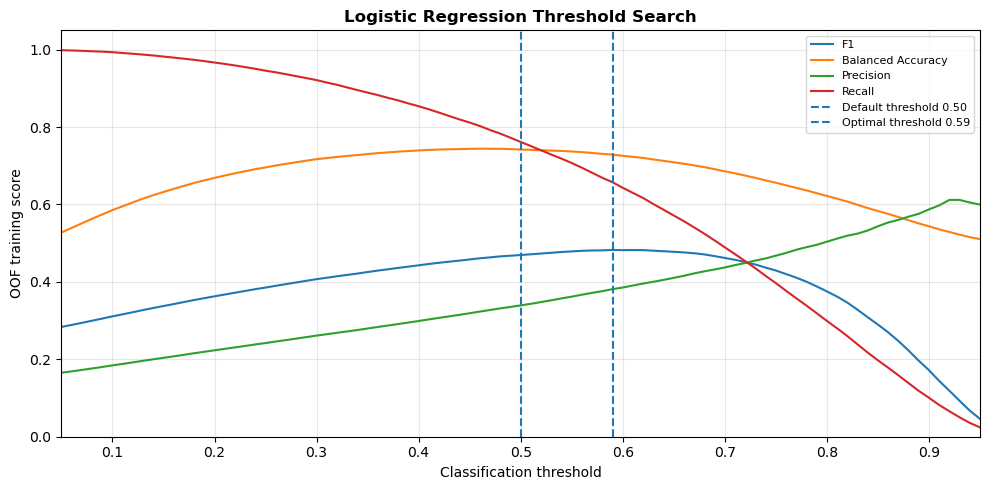

🏃 View run team02_s203_lr_threshold_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4d0a1f65fd754905bb85a4459886cb10
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Threshold tuning run ID: 4d0a1f65fd754905bb85a4459886cb10

Held-out test is still untouched. The optimized threshold will be applied only in the final evaluation.


In [10]:
from sklearn.model_selection import cross_val_predict

# ============================================================
# Threshold-search settings
# ============================================================
THRESHOLD_OBJECTIVE = "f1"

THRESHOLD_MIN = 0.05
THRESHOLD_MAX = 0.95
THRESHOLD_STEP = 0.01

thresholds = np.round(
    np.arange(
        THRESHOLD_MIN,
        THRESHOLD_MAX + THRESHOLD_STEP / 2,
        THRESHOLD_STEP,
    ),
    2,
)

# Recreate the CV-selected Logistic Regression configuration.
threshold_model = LogisticRegression(
    C=SELECTED_C,
    class_weight=SELECTED_CLASS_WEIGHT,
    penalty="l2",
    solver="lbfgs",
    max_iter=3000,
    random_state=RANDOM_STATE,
)

# ------------------------------------------------------------
# OUT-OF-FOLD probabilities from TRAINING DATA ONLY.
# ------------------------------------------------------------
oof_proba = cross_val_predict(
    threshold_model,
    X_train,
    y_train,
    cv=CV,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_rows = []

for threshold in thresholds:
    row = {
        "threshold": float(threshold),
        **binary_operating_metrics(
            y_train,
            oof_proba,
            threshold=float(threshold),
        ),
    }
    threshold_rows.append(row)

threshold_results = pd.DataFrame(
    threshold_rows
)

# ------------------------------------------------------------
# Select optimal threshold:
# 1. F1
# 2. balanced accuracy
# 3. recall
# ------------------------------------------------------------
threshold_results = threshold_results.sort_values(
    by=[
        "f1",
        "balanced_accuracy",
        "recall",
    ],
    ascending=[
        False,
        False,
        False,
    ],
).reset_index(drop=True)

best_threshold_row = threshold_results.iloc[0]

OPTIMAL_THRESHOLD = float(
    best_threshold_row["threshold"]
)

OOF_THRESHOLD_F1 = float(
    best_threshold_row["f1"]
)
OOF_THRESHOLD_BALANCED_ACCURACY = float(
    best_threshold_row["balanced_accuracy"]
)
OOF_THRESHOLD_PRECISION = float(
    best_threshold_row["precision"]
)
OOF_THRESHOLD_RECALL = float(
    best_threshold_row["recall"]
)
OOF_THRESHOLD_SPECIFICITY = float(
    best_threshold_row["specificity"]
)
OOF_THRESHOLD_FPR = float(
    best_threshold_row["fpr"]
)
OOF_THRESHOLD_FNR = float(
    best_threshold_row["fnr"]
)

default_match = threshold_results[
    np.isclose(
        threshold_results["threshold"],
        0.50,
    )
]

if default_match.empty:
    raise RuntimeError(
        "Default threshold 0.50 is missing "
        "from the threshold search."
    )

default_threshold_row = default_match.iloc[0]

DEFAULT_THRESHOLD_F1 = float(
    default_threshold_row["f1"]
)
DEFAULT_THRESHOLD_BALANCED_ACCURACY = float(
    default_threshold_row["balanced_accuracy"]
)
DEFAULT_THRESHOLD_PRECISION = float(
    default_threshold_row["precision"]
)
DEFAULT_THRESHOLD_RECALL = float(
    default_threshold_row["recall"]
)
DEFAULT_THRESHOLD_SPECIFICITY = float(
    default_threshold_row["specificity"]
)
DEFAULT_THRESHOLD_FPR = float(
    default_threshold_row["fpr"]
)
DEFAULT_THRESHOLD_FNR = float(
    default_threshold_row["fnr"]
)

print("=" * 72)
print("LOGISTIC REGRESSION THRESHOLD TUNING — OOF TRAINING DATA")
print("=" * 72)
print(f"Selected C                 : {SELECTED_C}")
print(f"Selected class_weight      : {SELECTED_CLASS_WEIGHT}")
print(f"Search range               : {THRESHOLD_MIN:.2f} – {THRESHOLD_MAX:.2f}")
print(f"Search step                : {THRESHOLD_STEP:.2f}")
print("-" * 72)
print("DEFAULT THRESHOLD")
print(f"Threshold                  : 0.50")
print(f"OOF F1                     : {DEFAULT_THRESHOLD_F1:.4f}")
print(f"OOF balanced accuracy      : {DEFAULT_THRESHOLD_BALANCED_ACCURACY:.4f}")
print(f"OOF precision              : {DEFAULT_THRESHOLD_PRECISION:.4f}")
print(f"OOF recall                 : {DEFAULT_THRESHOLD_RECALL:.4f}")
print(f"OOF specificity            : {DEFAULT_THRESHOLD_SPECIFICITY:.4f}")
print(f"OOF FPR                    : {DEFAULT_THRESHOLD_FPR:.4f}")
print(f"OOF FNR                    : {DEFAULT_THRESHOLD_FNR:.4f}")
print("-" * 72)
print("OPTIMIZED THRESHOLD")
print(f"Threshold                  : {OPTIMAL_THRESHOLD:.2f}")
print(f"OOF F1                     : {OOF_THRESHOLD_F1:.4f}")
print(f"OOF balanced accuracy      : {OOF_THRESHOLD_BALANCED_ACCURACY:.4f}")
print(f"OOF precision              : {OOF_THRESHOLD_PRECISION:.4f}")
print(f"OOF recall                 : {OOF_THRESHOLD_RECALL:.4f}")
print(f"OOF specificity            : {OOF_THRESHOLD_SPECIFICITY:.4f}")
print(f"OOF FPR                    : {OOF_THRESHOLD_FPR:.4f}")
print(f"OOF FNR                    : {OOF_THRESHOLD_FNR:.4f}")
print("=" * 72)

print("\nTop 10 threshold candidates:")
display_threshold_cols = [
    "threshold",
    "f1",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "fpr",
    "fnr",
]
print(
    threshold_results[
        display_threshold_cols
    ].head(10).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

# ------------------------------------------------------------
# Log threshold search to MLflow.
# ------------------------------------------------------------
with mlflow.start_run(
    run_name=f"{TEAM_ID}_{STUDENT_ID}_lr_threshold_tuning"
) as threshold_run:

    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "threshold_tuning",
        "model_family": "LogisticRegression",
        "selection_eligible": "false",
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
    })

    mlflow.log_params({
        "selected_C": SELECTED_C,
        "selected_class_weight": str(SELECTED_CLASS_WEIGHT),
        "threshold_objective": THRESHOLD_OBJECTIVE,
        "threshold_min": THRESHOLD_MIN,
        "threshold_max": THRESHOLD_MAX,
        "threshold_step": THRESHOLD_STEP,
        "n_thresholds": len(thresholds),
        "cv_folds": CV_FOLDS,
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
    })

    mlflow.log_metrics({
        "default_threshold": 0.50,
        "default_oof_f1": DEFAULT_THRESHOLD_F1,
        "default_oof_balanced_accuracy": DEFAULT_THRESHOLD_BALANCED_ACCURACY,
        "default_oof_precision": DEFAULT_THRESHOLD_PRECISION,
        "default_oof_recall": DEFAULT_THRESHOLD_RECALL,
        "default_oof_specificity": DEFAULT_THRESHOLD_SPECIFICITY,
        "default_oof_fpr": DEFAULT_THRESHOLD_FPR,
        "default_oof_fnr": DEFAULT_THRESHOLD_FNR,
        "optimal_threshold": OPTIMAL_THRESHOLD,
        "optimal_oof_f1": OOF_THRESHOLD_F1,
        "optimal_oof_balanced_accuracy": OOF_THRESHOLD_BALANCED_ACCURACY,
        "optimal_oof_precision": OOF_THRESHOLD_PRECISION,
        "optimal_oof_recall": OOF_THRESHOLD_RECALL,
        "optimal_oof_specificity": OOF_THRESHOLD_SPECIFICITY,
        "optimal_oof_fpr": OOF_THRESHOLD_FPR,
        "optimal_oof_fnr": OOF_THRESHOLD_FNR,
    })

    with tempfile.TemporaryDirectory() as tmp:
        tmp_path = Path(tmp)

        csv_path = (
            tmp_path
            / "threshold_search.csv"
        )

        threshold_results.sort_values(
            "threshold"
        ).to_csv(
            csv_path,
            index=False,
        )

        mlflow.log_artifact(
            str(csv_path),
            artifact_path="threshold_tuning",
        )

        threshold_plot = threshold_results.sort_values(
            "threshold"
        )

        fig, ax = plt.subplots(
            figsize=(10, 5)
        )

        ax.plot(
            threshold_plot["threshold"],
            threshold_plot["f1"],
            label="F1",
        )
        ax.plot(
            threshold_plot["threshold"],
            threshold_plot["balanced_accuracy"],
            label="Balanced Accuracy",
        )
        ax.plot(
            threshold_plot["threshold"],
            threshold_plot["precision"],
            label="Precision",
        )
        ax.plot(
            threshold_plot["threshold"],
            threshold_plot["recall"],
            label="Recall",
        )

        ax.axvline(
            0.50,
            linestyle="--",
            label="Default threshold 0.50",
        )

        ax.axvline(
            OPTIMAL_THRESHOLD,
            linestyle="--",
            label=(
                f"Optimal threshold "
                f"{OPTIMAL_THRESHOLD:.2f}"
            ),
        )

        ax.set_xlabel(
            "Classification threshold"
        )
        ax.set_ylabel(
            "OOF training score"
        )
        ax.set_title(
            "Logistic Regression Threshold Search",
            fontweight="bold",
        )
        ax.set_xlim(
            THRESHOLD_MIN,
            THRESHOLD_MAX,
        )
        ax.set_ylim(
            0,
            1.05,
        )
        ax.legend(
            fontsize=8,
        )
        ax.grid(
            alpha=0.3,
        )

        plt.tight_layout()

        plot_path = (
            tmp_path
            / "threshold_search.png"
        )

        fig.savefig(
            plot_path,
            dpi=120,
            bbox_inches="tight",
        )

        mlflow.log_artifact(
            str(plot_path),
            artifact_path="threshold_tuning",
        )

        plt.show()
        plt.close()

    THRESHOLD_TUNING_RUN_ID = (
        threshold_run.info.run_id
    )

print(
    f"\nThreshold tuning run ID: "
    f"{THRESHOLD_TUNING_RUN_ID}"
)

print(
    "\nHeld-out test is still untouched. "
    "The optimized threshold will be applied "
    "only in the final evaluation."
)


## Interpretation Comment - Threshold Optimisation

Threshold optimisation used training-only out-of-fold probabilities from the selected balanced model.

At threshold `0.50`, OOF F1 was `0.4695`, balanced accuracy `0.7421`, precision `0.3394`, recall `0.7615`, specificity `0.7227`, FPR `0.2773` and FNR `0.2385`. The F1 search selected threshold `0.59`, where F1 increased to `0.4827` and precision to `0.3813`, while recall decreased to `0.6575` and balanced accuracy to `0.7290`. Specificity improved to `0.8004` and FPR decreased to `0.1996`.

The result shows that threshold `0.59` provides a higher-F1 operating point with fewer false positives, at the cost of more false negatives and lower recall. This is an operating trade-off rather than an improvement in the underlying probability ranking.


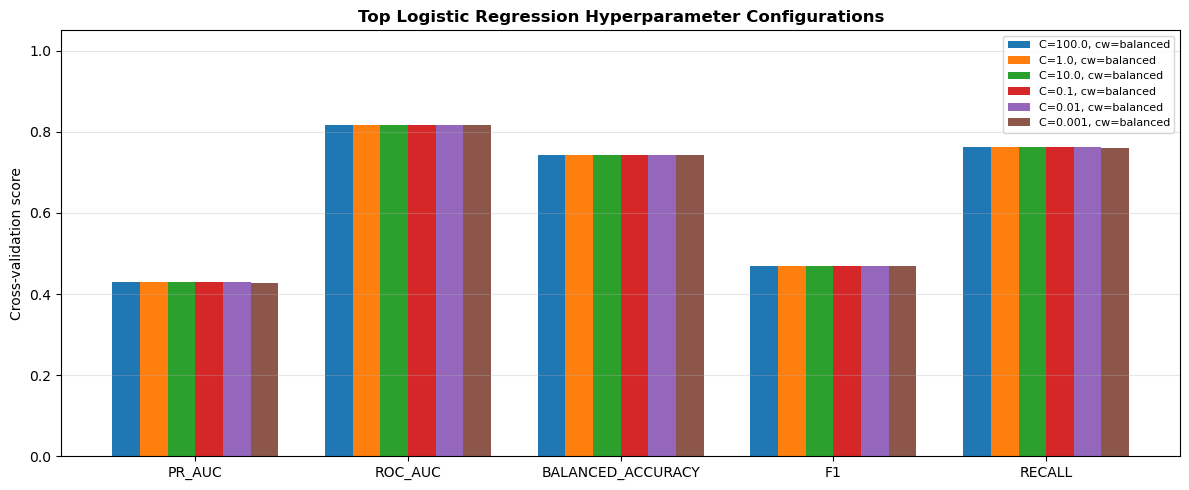

In [11]:
# Compare the top Logistic Regression hyperparameter configurations.
top_runs = eligible.head(6)

metric_cols = [
    "metrics.cv_pr_auc_mean",
    "metrics.cv_roc_auc_mean",
    "metrics.cv_balanced_accuracy_mean",
    "metrics.cv_f1_mean",
    "metrics.cv_recall_mean",
]

available_metrics = [
    c
    for c in metric_cols
    if c in top_runs.columns
]

fig, ax = plt.subplots(
    figsize=(12, 5)
)

labels = [
    c.replace("metrics.cv_", "")
    .replace("_mean", "")
    .upper()
    for c in available_metrics
]

x = np.arange(len(labels))
n_runs = max(len(top_runs), 1)
width = min(0.13, 0.78 / n_runs)

for idx, (_, row) in enumerate(
    top_runs.iterrows()
):
    values = [
        row.get(metric, np.nan)
        for metric in available_metrics
    ]

    run_label = (
        f"C={row.get('params.C', '?')}, "
        f"cw={row.get('params.class_weight', '?')}"
    )

    ax.bar(
        x + idx * width,
        values,
        width,
        label=run_label,
    )

ax.set_xticks(
    x + width * (n_runs - 1) / 2
)

ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cross-validation score")

ax.set_title(
    "Top Logistic Regression Hyperparameter Configurations",
    fontweight="bold",
)

ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Hyperparameter Comparison Plot — Interpretation

The comparison plot shows that the leading Logistic Regression candidates have very similar PR-AUC and ROC-AUC values. The larger differences appear in operating-point metrics such as recall, F1 and balanced accuracy when class weighting changes.

This visual pattern is consistent with the full-precision ranking: the higher balanced `C` values form a performance plateau, so the chart does not provide evidence of a large practical advantage for one high `C` value over the others.


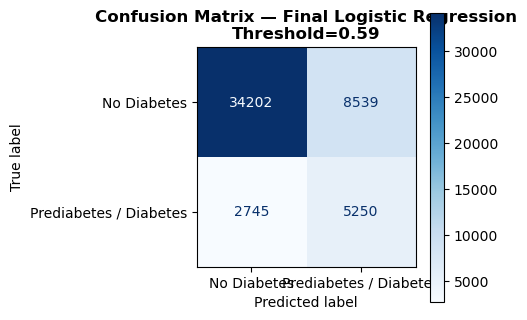

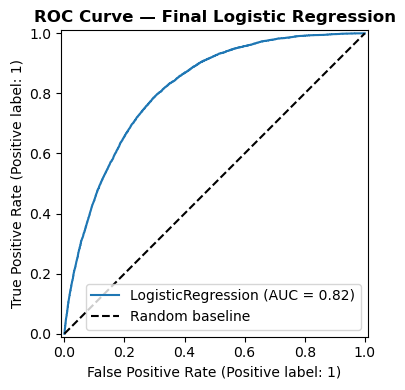

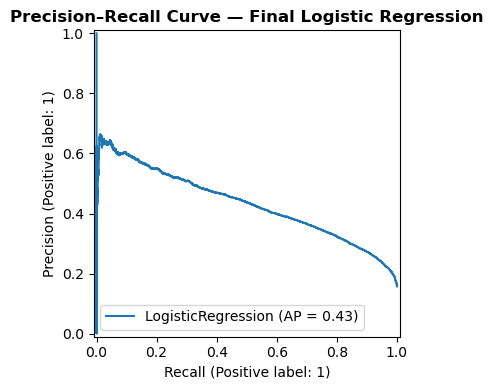

2026/08/21 23:34:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run team02_s203_final_logistic_regression at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/82bc9a4720e04a50ae942128305eb90d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
FINAL HELD-OUT TEST RESULTS
Selected candidate : lr_candidate_12
Model family       : LogisticRegression
Selection CV PR-AUC: 0.429813
Selection CV ROC   : 0.817737
Decision threshold : 0.59
Threshold OOF F1   : 0.4827
------------------------------------------------------------------------
test_accuracy               : 0.7776
test_auc_roc                : 0.8176
test_balanced_accuracy      : 0.7284
test_f1                     : 0.4820
test_fn                     : 2,745
test_fnr                    : 0.3433
test_fp                     : 8,539
test_fpr                    : 0.1998
test_pr_auc                 : 0.4327
test_precision              : 0.3807
test_recall                 : 0.6567
test_specificity            : 0.8002
test_tn                  

In [12]:
# ==========================================================
# Final Held-Out Evaluation + Legacy Deployment Quality Gate
# ==========================================================
#
# This is the FIRST point in the notebook where X_test/y_test
# are used for model evaluation.
#
# The ROC-AUC gate is retained for downstream compatibility,
# but Final Report model justification must use the full
# multi-metric and error/fairness/robustness evidence.
# ==========================================================

QUALITY_GATE_METRIC = "test_auc_roc"
QUALITY_GATE = 0.75

selected_candidate_uri = f"runs:/{SELECTED_CANDIDATE_RUN_ID}/model"

# Load the CV-selected candidate and refit it on ALL training data.
selected_model = mlflow.sklearn.load_model(selected_candidate_uri)
selected_model.fit(X_train, y_train)

# Evaluate the held-out test ONCE after model + threshold selection.
final_metrics = evaluate_final_model(
    selected_model,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=OPTIMAL_THRESHOLD,
)

final_run_name = f"{TEAM_ID}_{STUDENT_ID}_final_logistic_regression"

with mlflow.start_run(run_name=final_run_name) as final_run:
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "final_holdout_evaluation",
        "model_family": SELECTED_MODEL_FAMILY,
        "selection_eligible": "false",
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
        "selected_candidate_name": SELECTED_CANDIDATE_NAME,
        "final_report_multi_metric_review": "required",
    })

    mlflow.log_params({
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
        "selected_candidate_name": SELECTED_CANDIDATE_NAME,
        "selected_model_family": SELECTED_MODEL_FAMILY,
        "primary_selection_metric": PRIMARY_SELECTION_METRIC,
        "cv_folds": CV_FOLDS,
        "quality_gate_metric": QUALITY_GATE_METRIC,
        "quality_gate_threshold": QUALITY_GATE,
        "classification_threshold": OPTIMAL_THRESHOLD,
        "threshold_objective": THRESHOLD_OBJECTIVE,
        "threshold_tuning_run_id": THRESHOLD_TUNING_RUN_ID,
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
        "full_dataset_rows": FULL_DATASET_ROWS,
        "n_features": len(FEATURE_COLUMNS),
    })

    mlflow.log_metrics({
        "selection_cv_pr_auc": BEST_CV_PR_AUC,
        "selection_cv_roc_auc": BEST_CV_ROC_AUC,
        "selected_threshold": OPTIMAL_THRESHOLD,
        "threshold_oof_f1": OOF_THRESHOLD_F1,
        "default_threshold_oof_f1": DEFAULT_THRESHOLD_F1,
        **final_metrics,
    })

    log_confusion_matrix(
        selected_model,
        X_test,
        y_test,
        "Final Logistic Regression",
        threshold=OPTIMAL_THRESHOLD,
    )
    log_roc_curve(
        selected_model,
        X_test,
        y_test,
        "Final Logistic Regression",
    )
    log_pr_curve(
        selected_model,
        X_test,
        y_test,
        "Final Logistic Regression",
    )

    # Explicit feature-set artifact.
    with tempfile.TemporaryDirectory() as tmp:
        feature_path = Path(tmp) / "feature_set.json"
        feature_path.write_text(
            json.dumps(
                {
                    "target": TARGET_COLUMN,
                    "n_features": len(FEATURE_COLUMNS),
                    "features": FEATURE_COLUMNS,
                    "leakage_exclusion": "Diabetes_012",
                },
                indent=2,
            ),
            encoding="utf-8",
        )
        mlflow.log_artifact(
            str(feature_path),
            artifact_path="final_report/model_definition",
        )

    mlflow.sklearn.log_model(selected_model, name="model")

    FINAL_RUN_ID = final_run.info.run_id

FINAL_TEST_AUC_ROC = final_metrics["test_auc_roc"]
FINAL_TEST_PR_AUC = final_metrics["test_pr_auc"]

QUALITY_GATE_PASSED = FINAL_TEST_AUC_ROC >= QUALITY_GATE

# Downstream compatibility:
BEST_RUN_ID = FINAL_RUN_ID
BEST_RUN_NAME = final_run_name
BEST_AUC = FINAL_TEST_AUC_ROC
BEST_MODEL_URI = (
    f"runs:/{BEST_RUN_ID}/model"
    if QUALITY_GATE_PASSED
    else None
)

client.set_tag(
    FINAL_RUN_ID,
    "quality_gate_passed",
    str(QUALITY_GATE_PASSED).lower(),
)

print("=" * 72)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 72)
print(f"Selected candidate : {SELECTED_CANDIDATE_NAME}")
print(f"Model family       : {SELECTED_MODEL_FAMILY}")
print(f"Selection CV PR-AUC: {BEST_CV_PR_AUC:.6f}")
print(f"Selection CV ROC   : {BEST_CV_ROC_AUC:.6f}")
print(f"Decision threshold : {OPTIMAL_THRESHOLD:.2f}")
print(f"Threshold OOF F1   : {OOF_THRESHOLD_F1:.4f}")
print("-" * 72)

for key, value in sorted(final_metrics.items()):
    if key.endswith(("_tn", "_fp", "_fn", "_tp")):
        print(f"{key:<28}: {int(value):,}")
    else:
        print(f"{key:<28}: {value:.4f}")

print("-" * 72)

if QUALITY_GATE_PASSED:
    print("LEGACY ROC-AUC QUALITY GATE: PASSED")
    print(f"Final Test ROC-AUC {FINAL_TEST_AUC_ROC:.4f} >= {QUALITY_GATE:.2f}")
    print(f"Final model URI: {BEST_MODEL_URI}")
else:
    print("LEGACY ROC-AUC QUALITY GATE: FAILED")
    print(f"Final Test ROC-AUC {FINAL_TEST_AUC_ROC:.4f} < {QUALITY_GATE:.2f}")
    print("Do not promote this model to the next stage.")

print("\nFinal Report note:")
print(
    "The ROC-AUC gate is NOT the sole approval criterion. "
    "Use PR-AUC, recall, precision, F1, specificity/FPR/FNR, "
    "error analysis, subgroup fairness and robustness evidence below."
)
print("=" * 72)


## 10. Final Held-Out Evaluation - Interpretation

The selected balanced Logistic Regression (`lr_candidate_12`, `C=100`, `class_weight="balanced"`) was evaluated on the held-out test set after hyperparameter and threshold selection.

At threshold `0.59`, the held-out results are ROC-AUC `0.8176`, PR-AUC `0.4327`, balanced accuracy `0.7284`, F1 `0.4820`, precision `0.3807`, recall `0.6567`, specificity `0.8002`, FPR `0.1998`, FNR `0.3433` and accuracy `0.7776`. The confusion matrix contains `34,202` true negatives, `8,539` false positives, `2,745` false negatives and `5,250` true positives.

The model therefore retains strong ranking performance while identifying about 65.7% of actual positive cases at the selected threshold. Precision remains about 38.1%, so a substantial number of positive flags are false positives. The ROC-AUC quality gate passed because `0.8176` exceeded the required `0.75`, although the broader performance picture is better represented by PR-AUC, recall, precision, F1 and the error-rate measures together.


## 11. Error Analysis — False Positives, False Negatives and Borderline Cases

Metric reporting alone is not sufficient for the Final Report. This section examines **representative errors** from the fixed final Logistic Regression model and fixed operating threshold.

- **False negative (FN):** actual positive, predicted negative. In a screening-support application this can mean a respondent with reported prediabetes/diabetes is not flagged for follow-up.
- **False positive (FP):** actual negative, predicted positive. This can increase unnecessary follow-up or concern.
- **Borderline case:** predicted probability is very close to the selected threshold. These cases are inherently sensitive to small probability changes and illustrate why the prototype should support screening decisions rather than act as a diagnosis.

This analysis is post-hoc and must not be used to retune the model or threshold.

In [13]:
# ============================================================
# Final Report Error Analysis
# ============================================================

test_proba = selected_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= OPTIMAL_THRESHOLD).astype(int)

test_analysis = X_test.copy()
test_analysis["actual"] = y_test.to_numpy()
test_analysis["probability"] = test_proba
test_analysis["predicted"] = test_pred
test_analysis["distance_to_threshold"] = np.abs(
    test_analysis["probability"] - OPTIMAL_THRESHOLD
)

test_analysis["error_type"] = np.select(
    [
        (test_analysis["actual"] == 1)
        & (test_analysis["predicted"] == 0),
        (test_analysis["actual"] == 0)
        & (test_analysis["predicted"] == 1),
    ],
    [
        "False Negative",
        "False Positive",
    ],
    default="Correct",
)

error_summary = (
    test_analysis["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)
error_summary["rate_of_test_set"] = (
    error_summary["count"] / len(test_analysis)
)

# Representative cases: show the most confident wrong predictions.
false_negatives = (
    test_analysis[
        test_analysis["error_type"] == "False Negative"
    ]
    .sort_values(
        "probability",
        ascending=True,
    )
)

false_positives = (
    test_analysis[
        test_analysis["error_type"] == "False Positive"
    ]
    .sort_values(
        "probability",
        ascending=False,
    )
)

borderline_cases = (
    test_analysis
    .sort_values("distance_to_threshold")
)

ERROR_REVIEW_FEATURES = [
    c
    for c in [
        "HighBP",
        "HighChol",
        "BMI",
        "GenHlth",
        "DiffWalk",
        "Age",
        "Sex",
        "Education",
        "Income",
    ]
    if c in test_analysis.columns
]

review_cols = (
    ERROR_REVIEW_FEATURES
    + [
        "actual",
        "predicted",
        "probability",
        "distance_to_threshold",
    ]
)

REPRESENTATIVE_N = 10

representative_fn = false_negatives[
    review_cols
].head(REPRESENTATIVE_N)

representative_fp = false_positives[
    review_cols
].head(REPRESENTATIVE_N)

representative_borderline = borderline_cases[
    review_cols
].head(20)

print("=" * 72)
print("ERROR TYPE SUMMARY")
print("=" * 72)
print(
    error_summary.to_string(
        index=False,
        formatters={
            "rate_of_test_set": lambda x: f"{x:.2%}"
        },
    )
)

print("\nRepresentative FALSE NEGATIVES")
print(
    representative_fn.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nRepresentative FALSE POSITIVES")
print(
    representative_fp.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nBORDERLINE CASES nearest the selected threshold")
print(
    representative_borderline.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nApplication interpretation:")
print(
    "- False negatives are especially important in screening support "
    "because positive respondents may not be flagged for follow-up."
)
print(
    "- False positives can increase unnecessary follow-up burden."
)
print(
    "- Borderline cases demonstrate that predictions near the threshold "
    "should not be treated as definitive diagnoses."
)

# Log reproducible error-analysis evidence to the final MLflow run.
with tempfile.TemporaryDirectory() as tmp:
    tmp_path = Path(tmp)

    files_to_log = {
        "error_summary.csv": error_summary,
        "representative_false_negatives.csv": representative_fn,
        "representative_false_positives.csv": representative_fp,
        "borderline_cases.csv": representative_borderline,
    }

    for filename, frame in files_to_log.items():
        path = tmp_path / filename
        frame.to_csv(path, index=False)
        client.log_artifact(
            FINAL_RUN_ID,
            str(path),
            artifact_path="final_report/error_analysis",
        )

client.set_tag(
    FINAL_RUN_ID,
    "error_analysis_completed",
    "true",
)


ERROR TYPE SUMMARY
    error_type  count rate_of_test_set
       Correct  39452           77.76%
False Positive   8539           16.83%
False Negative   2745            5.41%

Representative FALSE NEGATIVES
 HighBP  HighChol     BMI  GenHlth  DiffWalk    Age    Sex  Education  Income  actual  predicted  probability  distance_to_threshold
 0.0000    0.0000 20.0000   1.0000    0.0000 4.0000 0.0000     6.0000  8.0000       1          0       0.0309                 0.5591
 0.0000    0.0000 27.0000   1.0000    0.0000 8.0000 1.0000     4.0000  8.0000       1          0       0.0390                 0.5510
 0.0000    0.0000 27.0000   3.0000    0.0000 2.0000 0.0000     5.0000  4.0000       1          0       0.0394                 0.5506
 0.0000    1.0000 25.0000   2.0000    0.0000 1.0000 0.0000     5.0000  3.0000       1          0       0.0408                 0.5492
 0.0000    0.0000 29.0000   1.0000    0.0000 1.0000 0.0000     5.0000  6.0000       1          0       0.0447                 0.

### Error-analysis interpretation

The held-out test set contains `2,745` false negatives and `8,539` false positives at threshold `0.59`. The FNR of `0.3433` means that about 34.3% of actual positive cases were not flagged, while the larger number of false positives indicates a substantial follow-up burden.

The displayed borderline errors have probabilities close to `0.59`, so small probability changes around the operating threshold can change the predicted class. The presence of high-confidence errors shows that not all mistakes are caused by threshold placement alone.

For this screening-support use case, these results support interpreting a positive prediction as a follow-up flag rather than as a diagnosis.


## 12. Fairness / Subgroup Error-Rate Analysis

The Final Report requires fairness testing or an equivalent assessment. This notebook evaluates the fixed final model across the project's documented subgroup variables:

- `Sex`
- `Age`
- `Education`
- `Income`

For each subgroup it reports sample size, prevalence, PR-AUC, ROC-AUC, recall, precision, F1, specificity, FPR and FNR.

The purpose is to identify **performance disparities**, especially differences in false-negative and false-positive rates. These descriptive tests do not prove that the model is fair.

In [14]:
# ============================================================
# Fairness / Subgroup Performance Analysis
# ============================================================

SUBGROUP_COLUMNS = [
    c
    for c in [
        "Sex",
        "Age",
        "Education",
        "Income",
    ]
    if c in test_analysis.columns
]

subgroup_rows = []

for attribute in SUBGROUP_COLUMNS:
    for group_value, group_df in test_analysis.groupby(
        attribute,
        dropna=False,
    ):
        y_group = group_df["actual"].to_numpy().astype(int)
        p_group = group_df["probability"].to_numpy()

        operating = binary_operating_metrics(
            y_group,
            p_group,
            threshold=OPTIMAL_THRESHOLD,
        )

        has_both_classes = np.unique(y_group).size == 2

        row = {
            "attribute": attribute,
            "group": str(group_value),
            "n": int(len(group_df)),
            "positive_rate": float(np.mean(y_group)),
            "pr_auc": (
                float(average_precision_score(y_group, p_group))
                if has_both_classes
                else np.nan
            ),
            "roc_auc": (
                float(roc_auc_score(y_group, p_group))
                if has_both_classes
                else np.nan
            ),
            **operating,
        }
        subgroup_rows.append(row)

subgroup_metrics = pd.DataFrame(subgroup_rows)

gap_rows = []

for attribute in SUBGROUP_COLUMNS:
    frame = subgroup_metrics[
        subgroup_metrics["attribute"] == attribute
    ]

    gap_row = {
        "attribute": attribute,
        "n_groups": int(frame["group"].nunique()),
    }

    for metric in [
        "recall",
        "precision",
        "f1",
        "specificity",
        "fpr",
        "fnr",
        "pr_auc",
    ]:
        values = frame[metric].dropna()
        gap_row[f"{metric}_gap_max_minus_min"] = (
            float(values.max() - values.min())
            if len(values) >= 2
            else np.nan
        )

    gap_rows.append(gap_row)

fairness_gap_summary = pd.DataFrame(gap_rows)

print("=" * 72)
print("SUBGROUP PERFORMANCE / FAIRNESS TEST")
print("=" * 72)

if subgroup_metrics.empty:
    print("No configured subgroup columns were found in X_test.")
else:
    for attribute in SUBGROUP_COLUMNS:
        print(f"\n--- {attribute} ---")
        display_cols = [
            "group",
            "n",
            "positive_rate",
            "pr_auc",
            "recall",
            "precision",
            "f1",
            "specificity",
            "fpr",
            "fnr",
        ]
        print(
            subgroup_metrics[
                subgroup_metrics["attribute"] == attribute
            ][display_cols]
            .round(4)
            .to_string(index=False)
        )

    print("\nFAIRNESS GAP SUMMARY")
    print(
        fairness_gap_summary
        .round(4)
        .to_string(index=False)
    )

    if not fairness_gap_summary.empty:
        largest_fnr_row = fairness_gap_summary.loc[
            fairness_gap_summary[
                "fnr_gap_max_minus_min"
            ].fillna(-np.inf).idxmax()
        ]
        print(
            "\nLargest observed FNR gap: "
            f"{largest_fnr_row['attribute']} = "
            f"{largest_fnr_row['fnr_gap_max_minus_min']:.4f}"
        )

print(
    "\nInterpretation caution: subgroup differences are descriptive "
    "evidence, not proof of fairness or unfairness. Consider subgroup "
    "sample size and prevalence before drawing conclusions."
)

with tempfile.TemporaryDirectory() as tmp:
    tmp_path = Path(tmp)

    metrics_path = tmp_path / "subgroup_fairness_metrics.csv"
    gaps_path = tmp_path / "subgroup_fairness_gap_summary.csv"

    subgroup_metrics.to_csv(
        metrics_path,
        index=False,
    )
    fairness_gap_summary.to_csv(
        gaps_path,
        index=False,
    )

    client.log_artifact(
        FINAL_RUN_ID,
        str(metrics_path),
        artifact_path="final_report/fairness",
    )
    client.log_artifact(
        FINAL_RUN_ID,
        str(gaps_path),
        artifact_path="final_report/fairness",
    )

client.set_tag(
    FINAL_RUN_ID,
    "fairness_test",
    "subgroup_error_rate_analysis_equivalent",
)
client.set_tag(
    FINAL_RUN_ID,
    "fairness_attributes",
    ",".join(SUBGROUP_COLUMNS),
)


SUBGROUP PERFORMANCE / FAIRNESS TEST

--- Sex ---
group     n  positive_rate  pr_auc  recall  precision     f1  specificity    fpr    fnr
  0.0 28192         0.1480  0.4391  0.6575     0.3880 0.4880       0.8199 0.1801 0.3425
  1.0 22544         0.1696  0.4265  0.6558     0.3731 0.4756       0.7750 0.2250 0.3442

--- Age ---
group    n  positive_rate  pr_auc  recall  precision     f1  specificity    fpr    fnr
  1.0 1091         0.0165  0.0709  0.0000     0.0000 0.0000       0.9907 0.0093 1.0000
  2.0 1587         0.0296  0.1612  0.1489     0.1750 0.1609       0.9786 0.0214 0.8511
  3.0 2166         0.0332  0.1953  0.2917     0.2917 0.2917       0.9756 0.0244 0.7083
  4.0 2784         0.0499  0.1830  0.2806     0.2617 0.2708       0.9584 0.0416 0.7194
  5.0 3286         0.0733  0.3094  0.3859     0.3298 0.3556       0.9379 0.0621 0.6141
  6.0 4080         0.1054  0.3562  0.4791     0.3829 0.4256       0.9090 0.0910 0.5209
  7.0 5163         0.1354  0.3875  0.5207     0.3788 0.4386     

### Fairness interpretation

The subgroup analysis shows materially different error-rate patterns across the evaluated attributes. The maximum FNR gaps are approximately `0.0017` for Sex, `0.7890` for Age, `0.3649` for Education and `0.4065` for Income.

Age has the largest observed disparity. In the held-out data, recall ranges from `0.0000` for Age group 1 to `0.7890` for Age group 13. The magnitude of these gaps shows that aggregate performance does not describe all subgroups equally well.

These results are descriptive rather than a formal fairness determination. Their interpretation depends on subgroup sample size, prevalence, ordinal coding and confusion-matrix counts, and they apply to this dataset and the fixed threshold `0.59`.


## 13. Explainability Test - Logistic Regression Coefficients

The coefficient table reports the direction of each model association and its odds ratio, `exp(coefficient)`. A positive coefficient increases the modelled odds of the positive class; a negative coefficient decreases them, with other predictors held constant.

For binary predictors, an odds ratio compares category 1 with category 0. For ordinal or continuous predictors, it represents a one-unit increase in the stored coding. Raw coefficient magnitudes are not directly comparable as real-world effect sizes because the predictors use different units and codings.

These coefficients describe model associations, not causal effects. The output labels must also be checked: a predictor with a positive coefficient must not be described as one of the strongest negative coefficients.

In [15]:
# ============================================================
# Logistic Regression Explainability
# ============================================================

if not hasattr(selected_model, "coef_"):
    raise TypeError(
        "Selected model does not expose Logistic Regression coefficients."
    )

coefficients = selected_model.coef_[0]

explainability_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "coefficient": coefficients,
})

explainability_df["odds_ratio"] = np.exp(
    explainability_df["coefficient"]
)
explainability_df["direction"] = np.where(
    explainability_df["coefficient"] >= 0,
    "positive",
    "negative",
)
explainability_df["absolute_coefficient"] = np.abs(
    explainability_df["coefficient"]
)

explainability_df = explainability_df.sort_values(
    "coefficient",
    ascending=False,
).reset_index(drop=True)

TOP_N_EXPLANATIONS = min(
    10,
    len(explainability_df),
)

top_positive_features = (
    explainability_df
    .sort_values("coefficient", ascending=False)
    .head(TOP_N_EXPLANATIONS)
)

top_negative_features = (
    explainability_df
    .sort_values("coefficient", ascending=True)
    .head(TOP_N_EXPLANATIONS)
)

print("=" * 72)
print("LOGISTIC REGRESSION EXPLAINABILITY")
print("=" * 72)

print("\nStrongest positive coefficients")
print(
    top_positive_features[
        [
            "feature",
            "coefficient",
            "odds_ratio",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nStrongest negative coefficients")
print(
    top_negative_features[
        [
            "feature",
            "coefficient",
            "odds_ratio",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print(
    "\nInterpretation caution: coefficients reflect model associations, "
    "not causation. Raw coefficient magnitudes are affected by predictor "
    "scale/coding and should not be treated as directly comparable "
    "real-world effect sizes."
)

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "logistic_regression_coefficients.csv"
    explainability_df.to_csv(
        path,
        index=False,
    )
    client.log_artifact(
        FINAL_RUN_ID,
        str(path),
        artifact_path="final_report/explainability",
    )

client.set_tag(
    FINAL_RUN_ID,
    "explainability_test",
    "logistic_regression_coefficients_and_odds_ratios",
)


LOGISTIC REGRESSION EXPLAINABILITY

Strongest positive coefficients
             feature  coefficient  odds_ratio
           CholCheck       1.2358      3.4410
              HighBP       0.6810      1.9759
            HighChol       0.5938      1.8108
             GenHlth       0.5527      1.7380
                 Sex       0.2517      1.2862
HeartDiseaseorAttack       0.2241      1.2512
                 Age       0.1516      1.1637
              Stroke       0.1027      1.1082
         NoDocbcCost       0.0961      1.1009
                 BMI       0.0737      1.0765

Strongest negative coefficients
          feature  coefficient  odds_ratio
HvyAlcoholConsump      -0.6126      0.5419
           Income      -0.0621      0.9397
           Fruits      -0.0531      0.9483
     PhysActivity      -0.0499      0.9513
        Education      -0.0436      0.9574
          Veggies      -0.0236      0.9767
           Smoker      -0.0119      0.9882
         PhysHlth      -0.0063      0.9938
      

## 14. Robustness / Stability Testing

Two equivalent robustness tests are performed on the fixed final solution:

**A. Bootstrap confidence intervals**  
Repeated resampling of the held-out predictions estimates the stability of PR-AUC, recall, precision, F1, specificity, FPR and FNR.

**B. Threshold sensitivity**  
The final threshold is perturbed by small amounts to show how sensitive recall, precision, F1, FPR and FNR are to the operating point.

The threshold-sensitivity results are **not** used to select a new threshold. They are post-hoc evidence of operational stability.

In [16]:
# ============================================================
# Robustness Test A: Bootstrap Confidence Intervals
# Robustness Test B: Threshold Sensitivity
# ============================================================

BOOTSTRAP_REPEATS = 200
BOOTSTRAP_CONFIDENCE = 0.95

rng = np.random.default_rng(RANDOM_STATE)

y_boot_source = y_test.to_numpy().astype(int)
p_boot_source = test_proba
n_test = len(y_boot_source)

bootstrap_rows = []

for i in range(BOOTSTRAP_REPEATS):
    sample_idx = rng.integers(
        0,
        n_test,
        size=n_test,
    )

    y_b = y_boot_source[sample_idx]
    p_b = p_boot_source[sample_idx]

    # With this large stratified test set both classes should be present,
    # but retain the guard for reproducibility.
    if np.unique(y_b).size < 2:
        continue

    operating = binary_operating_metrics(
        y_b,
        p_b,
        threshold=OPTIMAL_THRESHOLD,
    )

    bootstrap_rows.append({
        "replicate": i + 1,
        "pr_auc": float(
            average_precision_score(y_b, p_b)
        ),
        "roc_auc": float(
            roc_auc_score(y_b, p_b)
        ),
        "precision": operating["precision"],
        "recall": operating["recall"],
        "f1": operating["f1"],
        "specificity": operating["specificity"],
        "fpr": operating["fpr"],
        "fnr": operating["fnr"],
    })

bootstrap_results = pd.DataFrame(
    bootstrap_rows
)

alpha = 1.0 - BOOTSTRAP_CONFIDENCE

ci_rows = []

for metric in [
    "pr_auc",
    "roc_auc",
    "precision",
    "recall",
    "f1",
    "specificity",
    "fpr",
    "fnr",
]:
    values = bootstrap_results[metric].dropna()

    ci_rows.append({
        "metric": metric,
        "bootstrap_mean": float(values.mean()),
        "ci_lower": float(
            values.quantile(alpha / 2)
        ),
        "ci_upper": float(
            values.quantile(1 - alpha / 2)
        ),
        "n_bootstrap": int(len(values)),
    })

bootstrap_ci = pd.DataFrame(ci_rows)

# ------------------------------------------------------------
# Threshold sensitivity: post-hoc robustness only.
# ------------------------------------------------------------
threshold_deltas = [
    -0.05,
    -0.02,
    0.00,
    0.02,
    0.05,
]

sensitivity_thresholds = sorted(
    set(
        round(
            float(
                np.clip(
                    OPTIMAL_THRESHOLD + delta,
                    0.01,
                    0.99,
                )
            ),
            4,
        )
        for delta in threshold_deltas
    )
)

sensitivity_rows = []

for threshold in sensitivity_thresholds:
    operating = binary_operating_metrics(
        y_test,
        test_proba,
        threshold=threshold,
    )

    sensitivity_rows.append({
        "threshold": threshold,
        **operating,
    })

threshold_sensitivity = pd.DataFrame(
    sensitivity_rows
)

print("=" * 72)
print(
    f"BOOTSTRAP {int(BOOTSTRAP_CONFIDENCE * 100)}% "
    "CONFIDENCE INTERVALS"
)
print("=" * 72)
print(
    bootstrap_ci
    .round(4)
    .to_string(index=False)
)

print("\nTHRESHOLD SENSITIVITY — POST-HOC ROBUSTNESS ONLY")
print(
    threshold_sensitivity[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "specificity",
            "fpr",
            "fnr",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print(
    "\nDo NOT choose a new threshold from this table. "
    "The operating threshold was fixed using training-only OOF predictions."
)

with tempfile.TemporaryDirectory() as tmp:
    tmp_path = Path(tmp)

    bootstrap_path = tmp_path / "bootstrap_metric_samples.csv"
    ci_path = tmp_path / "bootstrap_confidence_intervals.csv"
    sensitivity_path = tmp_path / "threshold_sensitivity.csv"

    bootstrap_results.to_csv(
        bootstrap_path,
        index=False,
    )
    bootstrap_ci.to_csv(
        ci_path,
        index=False,
    )
    threshold_sensitivity.to_csv(
        sensitivity_path,
        index=False,
    )

    client.log_artifact(
        FINAL_RUN_ID,
        str(bootstrap_path),
        artifact_path="final_report/robustness",
    )
    client.log_artifact(
        FINAL_RUN_ID,
        str(ci_path),
        artifact_path="final_report/robustness",
    )
    client.log_artifact(
        FINAL_RUN_ID,
        str(sensitivity_path),
        artifact_path="final_report/robustness",
    )

client.set_tag(
    FINAL_RUN_ID,
    "robustness_test",
    "bootstrap_ci_and_threshold_sensitivity",
)
client.set_tag(
    FINAL_RUN_ID,
    "bootstrap_repeats",
    str(BOOTSTRAP_REPEATS),
)


BOOTSTRAP 95% CONFIDENCE INTERVALS
     metric  bootstrap_mean  ci_lower  ci_upper  n_bootstrap
     pr_auc          0.4325    0.4210    0.4444          200
    roc_auc          0.8176    0.8131    0.8224          200
  precision          0.3807    0.3729    0.3886          200
     recall          0.6563    0.6475    0.6665          200
         f1          0.4819    0.4740    0.4905          200
specificity          0.8005    0.7970    0.8041          200
        fpr          0.1995    0.1959    0.2030          200
        fnr          0.3437    0.3335    0.3525          200

THRESHOLD SENSITIVITY — POST-HOC ROBUSTNESS ONLY
 threshold  precision  recall     f1  specificity    fpr    fnr
      0.54     0.3590  0.7186 0.4788       0.7600 0.2400 0.2814
      0.57     0.3721  0.6826 0.4816       0.7845 0.2155 0.3174
      0.59     0.3807  0.6567 0.4820       0.8002 0.1998 0.3433
      0.61     0.3903  0.6289 0.4817       0.8162 0.1838 0.3711
      0.64     0.4033  0.5817 0.4764       0.8

### Robustness interpretation

Across 200 bootstrap resamples of the fixed held-out predictions, the 95% intervals are relatively narrow: ROC-AUC `0.8131–0.8224`, PR-AUC `0.4210–0.4444`, precision `0.3729–0.3886`, recall `0.6475–0.6665`, F1 `0.4740–0.4905`, specificity `0.7970–0.8041`, FPR `0.1959–0.2030` and FNR `0.3335–0.3525`.

The post-hoc threshold-sensitivity results show that F1 is nearly flat around thresholds `0.57–0.61` (`0.4816–0.4820`). As the threshold increases from `0.54` to `0.64`, recall decreases from `0.7186` to `0.5817`, while precision and specificity increase.

This indicates that the fixed model's held-out performance is reasonably stable to test-sample resampling and that the selected operating point lies in a relatively flat local F1 region. The bootstrap does not include model retraining, so it measures prediction-sample uncertainty rather than full training-process uncertainty.


## 15. Final Report Evidence Summary

The next cell creates a compact, machine-readable summary of the final Logistic Regression evidence and logs it to the final MLflow run. It is intended to support the report and downstream handover without manually retyping metrics.

In [17]:
# ============================================================
# Compact Final Report Evidence Summary
# ============================================================

fairness_gap_records = (
    json.loads(
        fairness_gap_summary.to_json(orient="records")
    )
    if not fairness_gap_summary.empty
    else []
)

bootstrap_ci_records = json.loads(
    bootstrap_ci.to_json(orient="records")
)

final_report_evidence = {
    "data_profile": DATA_PROFILE,
    "full_dataset_rows": int(FULL_DATASET_ROWS),
    "profile_rows": int(PROFILE_ROWS),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(FEATURE_COLUMNS)),
    "features": FEATURE_COLUMNS,
    "selected_lr_candidate": SELECTED_CANDIDATE_NAME,
    "selected_C": float(SELECTED_C),
    "selected_class_weight": SELECTED_CLASS_WEIGHT,
    "selection_cv_pr_auc": float(BEST_CV_PR_AUC),
    "selection_cv_roc_auc": float(BEST_CV_ROC_AUC),
    "classification_threshold": float(OPTIMAL_THRESHOLD),
    "final_test_metrics": {
        key: float(value)
        for key, value in final_metrics.items()
    },
    "error_counts": {
        "false_negative": int(final_metrics["test_fn"]),
        "false_positive": int(final_metrics["test_fp"]),
        "true_negative": int(final_metrics["test_tn"]),
        "true_positive": int(final_metrics["test_tp"]),
    },
    "fairness_attributes": SUBGROUP_COLUMNS,
    "fairness_gap_summary": fairness_gap_records,
    "explainability_method": (
        "Logistic Regression coefficients and odds ratios"
    ),
    "robustness": {
        "bootstrap_repeats": int(BOOTSTRAP_REPEATS),
        "bootstrap_confidence": float(BOOTSTRAP_CONFIDENCE),
        "bootstrap_ci": bootstrap_ci_records,
        "threshold_sensitivity_tested": True,
        "threshold_sensitivity_used_for_retuning": False,
    },
    "mlflow_final_run_id": FINAL_RUN_ID,
    "mlflow_model_uri": BEST_MODEL_URI,
}

evidence_path = Path(
    "final_report_logistic_regression_evidence.json"
)
evidence_path.write_text(
    json.dumps(
        final_report_evidence,
        indent=2,
    ),
    encoding="utf-8",
)

client.log_artifact(
    FINAL_RUN_ID,
    str(evidence_path),
    artifact_path="final_report",
)

client.set_tag(
    FINAL_RUN_ID,
    "final_report_evidence_complete",
    "true",
)

print("=" * 72)
print("FINAL REPORT LOGISTIC REGRESSION EVIDENCE SUMMARY")
print("=" * 72)
print(f"Dataset profile      : {DATA_PROFILE}")
print(f"Full dataset rows    : {FULL_DATASET_ROWS:,}")
print(f"Train / test rows    : {len(X_train):,} / {len(X_test):,}")
print(f"Number of features   : {len(FEATURE_COLUMNS)}")
print(f"Selected candidate   : {SELECTED_CANDIDATE_NAME}")
print(f"Selected C           : {SELECTED_C}")
print(f"Selected class weight: {SELECTED_CLASS_WEIGHT}")
print(f"Selected threshold   : {OPTIMAL_THRESHOLD:.2f}")
print(f"CV PR-AUC            : {BEST_CV_PR_AUC:.6f}")
print(f"Test PR-AUC          : {final_metrics['test_pr_auc']:.4f}")
print(f"Test recall          : {final_metrics['test_recall']:.4f}")
print(f"Test precision       : {final_metrics['test_precision']:.4f}")
print(f"Test F1              : {final_metrics['test_f1']:.4f}")
print(f"Test specificity     : {final_metrics['test_specificity']:.4f}")
print(f"Test FPR             : {final_metrics['test_fpr']:.4f}")
print(f"Test FNR             : {final_metrics['test_fnr']:.4f}")
print(f"False negatives      : {int(final_metrics['test_fn']):,}")
print(f"False positives      : {int(final_metrics['test_fp']):,}")
print(f"MLflow final run     : {FINAL_RUN_ID}")
print(f"Model URI            : {BEST_MODEL_URI}")
print(f"Evidence JSON        : {evidence_path}")
print("=" * 72)


FINAL REPORT LOGISTIC REGRESSION EVIDENCE SUMMARY
Dataset profile      : full
Full dataset rows    : 253,680
Train / test rows    : 202,944 / 50,736
Number of features   : 21
Selected candidate   : lr_candidate_12
Selected C           : 100.0
Selected class weight: balanced
Selected threshold   : 0.59
CV PR-AUC            : 0.429813
Test PR-AUC          : 0.4327
Test recall          : 0.6567
Test precision       : 0.3807
Test F1              : 0.4820
Test specificity     : 0.8002
Test FPR             : 0.1998
Test FNR             : 0.3433
False negatives      : 2,745
False positives      : 8,539
MLflow final run     : 82bc9a4720e04a50ae942128305eb90d
Model URI            : runs:/82bc9a4720e04a50ae942128305eb90d/model
Evidence JSON        : final_report_logistic_regression_evidence.json


In [18]:
# ==========================================================
# Notebook 03 Inputs
# ==========================================================

print("\nValues for Notebook 03:\n")
print(f'DATA_PROFILE               = "{DATA_PROFILE}"')
print(f"PROFILE_FRACTION           = {PROFILE_FRACTION}")
print(f"PROFILE_ROWS               = {PROFILE_ROWS}")

print(f'SELECTED_CANDIDATE_RUN_ID = "{SELECTED_CANDIDATE_RUN_ID}"')
print(f'SELECTED_MODEL_FAMILY     = "{SELECTED_MODEL_FAMILY}"')
print(f"BEST_CV_PR_AUC            = {BEST_CV_PR_AUC:.8f}")
print(f'BEST_RUN_ID               = "{BEST_RUN_ID}"')
print(f'BEST_RUN_NAME             = "{BEST_RUN_NAME}"')
print(f"FINAL_TEST_AUC_ROC        = {FINAL_TEST_AUC_ROC:.6f}")
print(f"FINAL_TEST_PR_AUC         = {FINAL_TEST_PR_AUC:.6f}")
print(f"FINAL_TEST_RECALL         = {final_metrics['test_recall']:.6f}")
print(f"FINAL_TEST_PRECISION      = {final_metrics['test_precision']:.6f}")
print(f"FINAL_TEST_F1             = {final_metrics['test_f1']:.6f}")
print(f"FINAL_TEST_SPECIFICITY    = {final_metrics['test_specificity']:.6f}")
print(f"FINAL_TEST_FPR            = {final_metrics['test_fpr']:.6f}")
print(f"FINAL_TEST_FNR            = {final_metrics['test_fnr']:.6f}")
print(f"QUALITY_GATE_PASSED       = {QUALITY_GATE_PASSED}")

if BEST_MODEL_URI is not None:
    print(f'BEST_MODEL_URI            = "{BEST_MODEL_URI}"')
else:
    print("BEST_MODEL_URI            = None")



Values for Notebook 03:

DATA_PROFILE               = "full"
PROFILE_FRACTION           = 1.0
PROFILE_ROWS               = 253680
SELECTED_CANDIDATE_RUN_ID = "74e8884c230349f3ad29021db15f54a2"
SELECTED_MODEL_FAMILY     = "LogisticRegression"
BEST_CV_PR_AUC            = 0.42981299
BEST_RUN_ID               = "82bc9a4720e04a50ae942128305eb90d"
BEST_RUN_NAME             = "team02_s203_final_logistic_regression"
FINAL_TEST_AUC_ROC        = 0.817565
FINAL_TEST_PR_AUC         = 0.432749
FINAL_TEST_RECALL         = 0.656660
FINAL_TEST_PRECISION      = 0.380738
FINAL_TEST_F1             = 0.482005
FINAL_TEST_SPECIFICITY    = 0.800215
FINAL_TEST_FPR            = 0.199785
FINAL_TEST_FNR            = 0.343340
QUALITY_GATE_PASSED       = True
BEST_MODEL_URI            = "runs:/82bc9a4720e04a50ae942128305eb90d/model"


## Interpretation Comment - Notebook 03 Handover Values

The handover cell records the full-data Model A configuration and final evaluation values for downstream use. It identifies the selected candidate run, final MLflow run, full-data profile, threshold `0.59`, CV PR-AUC `0.42981299` and the final held-out metrics.

The output therefore provides a reproducible Model A handover record. It also shows that Logistic Regression remains a Model A candidate rather than the final team champion, because the separate model-family comparison with XGBoost has not yet been completed.


In [19]:
# Write the final selection information so Notebook 03 can read it.
best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,

    # Candidate selection — training CV only
    "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
    "selected_candidate_name": SELECTED_CANDIDATE_NAME,
    "selected_model_family": SELECTED_MODEL_FAMILY,
    "selected_C": SELECTED_C,
    "selected_class_weight": SELECTED_CLASS_WEIGHT,
    "classification_threshold": float(OPTIMAL_THRESHOLD),
    "threshold_objective": THRESHOLD_OBJECTIVE,
    "threshold_tuning_run_id": THRESHOLD_TUNING_RUN_ID,
    "threshold_default": 0.50,
    "threshold_default_oof_f1": float(DEFAULT_THRESHOLD_F1),
    "threshold_optimal_oof_f1": float(OOF_THRESHOLD_F1),
    "threshold_optimal_oof_balanced_accuracy": float(OOF_THRESHOLD_BALANCED_ACCURACY),
    "threshold_optimal_oof_precision": float(OOF_THRESHOLD_PRECISION),
    "threshold_optimal_oof_recall": float(OOF_THRESHOLD_RECALL),
    "threshold_optimal_oof_specificity": float(OOF_THRESHOLD_SPECIFICITY),
    "threshold_optimal_oof_fpr": float(OOF_THRESHOLD_FPR),
    "threshold_optimal_oof_fnr": float(OOF_THRESHOLD_FNR),
    "selection_metric": PRIMARY_SELECTION_METRIC,
    "best_cv_pr_auc": float(BEST_CV_PR_AUC),
    "best_cv_roc_auc": float(BEST_CV_ROC_AUC),

    # Final held-out evaluation
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(FINAL_TEST_AUC_ROC),  # legacy downstream key
    "final_test_auc_roc": float(FINAL_TEST_AUC_ROC),
    "final_test_pr_auc": float(FINAL_TEST_PR_AUC),
    "final_test_balanced_accuracy": float(final_metrics["test_balanced_accuracy"]),
    "final_test_f1": float(final_metrics["test_f1"]),
    "final_test_precision": float(final_metrics["test_precision"]),
    "final_test_recall": float(final_metrics["test_recall"]),
    "final_test_specificity": float(final_metrics["test_specificity"]),
    "final_test_fpr": float(final_metrics["test_fpr"]),
    "final_test_fnr": float(final_metrics["test_fnr"]),
    "final_test_tn": int(final_metrics["test_tn"]),
    "final_test_fp": int(final_metrics["test_fp"]),
    "final_test_fn": int(final_metrics["test_fn"]),
    "final_test_tp": int(final_metrics["test_tp"]),

    # Legacy deployment gate — not the sole Final Report acceptance criterion
    "quality_gate_metric": QUALITY_GATE_METRIC,
    "quality_gate_threshold": float(QUALITY_GATE),
    "quality_gate_passed": bool(QUALITY_GATE_PASSED),
    "best_model_uri": BEST_MODEL_URI,

    # Final Report tests
    "error_analysis_completed": True,
    "fairness_test": "subgroup_error_rate_analysis_equivalent",
    "fairness_attributes": SUBGROUP_COLUMNS,
    "fairness_gap_summary": json.loads(fairness_gap_summary.to_json(orient="records")),
    "explainability_test": "logistic_regression_coefficients_and_odds_ratios",
    "robustness_test": "bootstrap_ci_and_threshold_sensitivity",
    "bootstrap_repeats": int(BOOTSTRAP_REPEATS),
    "bootstrap_confidence": float(BOOTSTRAP_CONFIDENCE),
    "bootstrap_confidence_intervals": json.loads(bootstrap_ci.to_json(orient="records")),

    # Feature set / dataset profile
    "target_column": TARGET_COLUMN,
    "feature_count": int(len(FEATURE_COLUMNS)),
    "feature_columns": FEATURE_COLUMNS,
    "data_profile": DATA_PROFILE,
    "profile_fraction": float(PROFILE_FRACTION),
    "profile_rows": int(PROFILE_ROWS),
    "full_dataset_rows": int(FULL_DATASET_ROWS),
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),

    # Tracking context
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "experiment_batch_id": EXPERIMENT_BATCH_ID,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

# Also log the handover JSON to the final run.
client.log_artifact(
    FINAL_RUN_ID,
    "best_model.json",
    artifact_path="handover",
)

print("Saved final model information to best_model.json")
print(json.dumps(best_model_info, indent=2))


Saved final model information to best_model.json
{
  "team_id": "team02",
  "student_id": "s203",
  "project_name": "diabetes",
  "selected_candidate_run_id": "74e8884c230349f3ad29021db15f54a2",
  "selected_candidate_name": "lr_candidate_12",
  "selected_model_family": "LogisticRegression",
  "selected_C": 100.0,
  "selected_class_weight": "balanced",
  "classification_threshold": 0.59,
  "threshold_objective": "f1",
  "threshold_tuning_run_id": "4d0a1f65fd754905bb85a4459886cb10",
  "threshold_default": 0.5,
  "threshold_default_oof_f1": 0.46949279972239893,
  "threshold_optimal_oof_f1": 0.4827095456162701,
  "threshold_optimal_oof_balanced_accuracy": 0.728980646431472,
  "threshold_optimal_oof_precision": 0.38132627341469166,
  "threshold_optimal_oof_recall": 0.6575261084359952,
  "threshold_optimal_oof_specificity": 0.8004351844269487,
  "threshold_optimal_oof_fpr": 0.19956481557305134,
  "threshold_optimal_oof_fnr": 0.34247389156400476,
  "selection_metric": "cv_pr_auc_mean",
  "bes

## Interpretation Comment - Final Handover Metadata

`best_model.json` was written successfully and contains the selected Logistic Regression configuration, threshold information, final held-out metrics, confusion-matrix counts, feature metadata, subgroup-analysis metadata, explainability metadata and bootstrap robustness evidence.

The result shows that the downstream handover is machine-readable and captures substantially more than the model URI alone, reducing the risk of losing the operating threshold or evaluation context between phases.


In [20]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

if BEST_MODEL_URI is None:
    print("Quality gate failed — no promotable model artifact is being handed off.")
else:
    artifacts = client.list_artifacts(BEST_RUN_ID)
    print("Final MLflow run artifacts:")
    for artifact in artifacts:
        print(artifact.path, artifact.is_dir)


Final MLflow run artifacts:
final_report True
handover True
plots True


In [21]:
# Load the final selected model and perform a small serving-style smoke test.
# This is NOT another aggregate model-selection evaluation.
if BEST_MODEL_URI is None:
    print("Quality gate failed — inference smoke test skipped.")
else:
    loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)

    sample = X_test.head(5)
    probas = loaded.predict_proba(sample)[:, 1]
    preds = (
        probas >= OPTIMAL_THRESHOLD
    ).astype(int)

    results = pd.DataFrame({
        "actual": y_test.head(5).values,
        "predicted": preds,
        "probability": probas.round(3),
        "correct": preds == y_test.head(5).values,
    })

    print("Sample predictions from final MLflow model:")
    print(results.to_string(index=False))


Sample predictions from final MLflow model:
 actual  predicted  probability  correct
      0          0        0.574     True
      0          0        0.163     True
      0          0        0.466     True
      0          0        0.392     True
      0          0        0.334     True


## Interpretation Comment - MLflow Artifact Check and Serving-Style Smoke Test

The final MLflow run contains the `final_report`, `handover` and `plots` artifact groups, and the saved model loaded successfully.

The five-row smoke test produced valid probabilities and thresholded predictions. All five displayed records are actual negatives and were predicted as negative. This confirms basic artifact loading and inference execution, but the sample is too narrow to provide additional performance evidence because it contains no positive cases.


In [22]:
print("=" * 72)
print("NOTEBOOK 02 — FINAL REPORT EVIDENCE COMPLETE")
print("=" * 72)
print(f"Experiment           : {MLFLOW_EXPERIMENT}")
print(f"Experiment Batch ID  : {EXPERIMENT_BATCH_ID}")
print(f"Dataset profile      : {DATA_PROFILE} ({PROFILE_FRACTION:.0%})")
print(f"Profile rows         : {PROFILE_ROWS:,} / {FULL_DATASET_ROWS:,}")
print(f"MLflow App           : {MLFLOW_APP_ARN}")
print("Selected model family: LogisticRegression")
print(f"Selected C           : {SELECTED_C}")
print(f"Selected class weight: {SELECTED_CLASS_WEIGHT}")
print(f"Optimal threshold    : {OPTIMAL_THRESHOLD:.2f}")
print(f"Threshold OOF F1     : {OOF_THRESHOLD_F1:.4f}")
print(f"Selection CV PR-AUC  : {BEST_CV_PR_AUC:.6f}")
print(f"Final Test ROC-AUC   : {FINAL_TEST_AUC_ROC:.4f}")
print(f"Final Test PR-AUC    : {FINAL_TEST_PR_AUC:.4f}")
print(f"Final Test Recall    : {final_metrics['test_recall']:.4f}")
print(f"Final Test Precision : {final_metrics['test_precision']:.4f}")
print(f"Final Test F1        : {final_metrics['test_f1']:.4f}")
print(f"Final Test Specificity: {final_metrics['test_specificity']:.4f}")
print(f"Final Test FPR       : {final_metrics['test_fpr']:.4f}")
print(f"Final Test FNR       : {final_metrics['test_fnr']:.4f}")
print(f"False Positives      : {int(final_metrics['test_fp']):,}")
print(f"False Negatives      : {int(final_metrics['test_fn']):,}")
print(f"Legacy quality gate  : {QUALITY_GATE_PASSED}")
print(f"Fairness attributes  : {SUBGROUP_COLUMNS}")
print(f"Bootstrap repeats    : {BOOTSTRAP_REPEATS}")
print(f"Final run ID         : {BEST_RUN_ID}")
print(f"Model URI            : {BEST_MODEL_URI}")
print()
print(
    "Next: use this notebook as Model A Final Report evidence. "
    "Team-level champion selection must compare it with Model B/XGBoost."
)


NOTEBOOK 02 — FINAL REPORT EVIDENCE COMPLETE
Experiment           : ITI113/team02/Experiment1
Experiment Batch ID  : 20260821T232057Z
Dataset profile      : full (100%)
Profile rows         : 253,680 / 253,680
MLflow App           : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
Selected model family: LogisticRegression
Selected C           : 100.0
Selected class weight: balanced
Optimal threshold    : 0.59
Threshold OOF F1     : 0.4827
Selection CV PR-AUC  : 0.429813
Final Test ROC-AUC   : 0.8176
Final Test PR-AUC    : 0.4327
Final Test Recall    : 0.6567
Final Test Precision : 0.3807
Final Test F1        : 0.4820
Final Test Specificity: 0.8002
Final Test FPR       : 0.1998
Final Test FNR       : 0.3433
False Positives      : 8,539
False Negatives      : 2,745
Legacy quality gate  : True
Fairness attributes  : ['Sex', 'Age', 'Education', 'Income']
Bootstrap repeats    : 200
Final run ID         : 82bc9a4720e04a50ae942128305eb90d
Model URI            : runs:/

## Interpretation Comment - Final Completion Summary

The full-data Logistic Regression workflow completed successfully.

The final selected Model A configuration is `lr_candidate_12` with `C=100`, `class_weight="balanced"` and threshold `0.59`. Selection CV PR-AUC is `0.429813`, and the training-only OOF F1 at the selected threshold is `0.4827`.

On the held-out test set, ROC-AUC is `0.8176`, PR-AUC `0.4327`, recall `0.6567`, precision `0.3807`, F1 `0.4820`, specificity `0.8002`, FPR `0.1998` and FNR `0.3433`, with `8,539` false positives and `2,745` false negatives.

The legacy ROC-AUC quality gate passed. Subgroup analysis was completed for Sex, Age, Education and Income, with the largest observed FNR gap across Age (`0.7890`). Robustness evidence used 200 bootstrap resamples. The final MLflow run ID is `82bc9a4720e04a50ae942128305eb90d`.

These results complete the Logistic Regression Model A evidence. Team-level champion selection remains a separate comparison against XGBoost.


---

## Final Report checklist before Notebook 03

- `DATA_PROFILE = "full"`
- Kernel restarted and all old outputs cleared
- Full cleaned dataset loaded and `Diabetes_012` excluded
- Stratified 80/20 split created with the held-out test protected
- Unweighted baseline completed for comparison
- All 12 LR candidates logged to MLflow
- Only `class_weight="balanced"` candidates marked selection-eligible
- Selected candidate passes the balanced-class-weight validation check
- Candidate selection uses full-precision CV PR-AUC, then ROC-AUC
- Threshold search uses OOF training probabilities from the selected balanced model
- Held-out test evaluated only after model and threshold selection
- Final evaluation and error, subgroup, explainability and robustness tests completed
- Final artifacts and `best_model.json` record `selected_class_weight="balanced"`
- Team-level comparison against XGBoost documented elsewhere

Continue to Notebook 03 only after the clean full-data balanced rerun completes without errors.

## Download model if needed

In [23]:
# ============================================================
# Download the final MLflow model artifact if promotion passed
# ============================================================

import os
import json
from pathlib import Path

import mlflow
import mlflow.sklearn

BEST_MODEL_JSON = "best_model.json"

if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(
        f"{BEST_MODEL_JSON} not found. Run the final selection/evaluation cells first."
    )

with open(BEST_MODEL_JSON, "r") as f:
    best_model_info = json.load(f)

print("Best model information:")
print(json.dumps(best_model_info, indent=2))

if not best_model_info.get("quality_gate_passed", False):
    raise RuntimeError(
        "The final model did not pass the quality gate. "
        "No model should be downloaded for staging promotion."
    )

mlflow_tracking_uri = best_model_info["mlflow_tracking_uri"]
best_model_uri = best_model_info["best_model_uri"]
best_run_id = best_model_info["best_run_id"]

mlflow.set_tracking_uri(mlflow_tracking_uri)

loaded_model = mlflow.sklearn.load_model(best_model_uri)

print("\nLoaded model type:")
print(type(loaded_model))

download_dir = Path("downloaded_mlflow_models")
download_dir.mkdir(parents=True, exist_ok=True)

local_model_path = mlflow.artifacts.download_artifacts(
    artifact_uri=best_model_uri,
    dst_path=str(download_dir),
)

print("\nDownloaded model folder:")
print(local_model_path)

print("\nDownloaded files:")
for root, dirs, files in os.walk(local_model_path):
    level = root.replace(local_model_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for filename in files:
        file_path = os.path.join(root, filename)
        size_bytes = os.path.getsize(file_path)
        print(f"{indent}  {filename}  ({size_bytes} bytes)")


Best model information:
{
  "team_id": "team02",
  "student_id": "s203",
  "project_name": "diabetes",
  "selected_candidate_run_id": "74e8884c230349f3ad29021db15f54a2",
  "selected_candidate_name": "lr_candidate_12",
  "selected_model_family": "LogisticRegression",
  "selected_C": 100.0,
  "selected_class_weight": "balanced",
  "classification_threshold": 0.59,
  "threshold_objective": "f1",
  "threshold_tuning_run_id": "4d0a1f65fd754905bb85a4459886cb10",
  "threshold_default": 0.5,
  "threshold_default_oof_f1": 0.46949279972239893,
  "threshold_optimal_oof_f1": 0.4827095456162701,
  "threshold_optimal_oof_balanced_accuracy": 0.728980646431472,
  "threshold_optimal_oof_precision": 0.38132627341469166,
  "threshold_optimal_oof_recall": 0.6575261084359952,
  "threshold_optimal_oof_specificity": 0.8004351844269487,
  "threshold_optimal_oof_fpr": 0.19956481557305134,
  "threshold_optimal_oof_fnr": 0.34247389156400476,
  "selection_metric": "cv_pr_auc_mean",
  "best_cv_pr_auc": 0.429812988


Loaded model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>



Downloaded model folder:
/home/sagemaker-user/workspace/s203_2730358J/02  Final Report /04_Optimised_Balanced_Class_Weight/downloaded_mlflow_models/model/

Downloaded files:
/
  MLmodel  (741 bytes)
  conda.yaml  (304 bytes)
  python_env.yaml  (123 bytes)
  model.pkl  (1220 bytes)
  requirements.txt  (166 bytes)
  registered_model_meta  (37 bytes)


## Interpretation Comment - Final Artifact Download and Portability Check

The final MLflow Logistic Regression artifact downloaded successfully with the expected model definition and environment files, including `MLmodel`, `model.pkl`, `conda.yaml`, `python_env.yaml` and `requirements.txt`.

The successful load and download show that the fitted model artifact is technically portable within the MLflow workflow. The preserved run ID, model URI, candidate run ID and `best_model.json` provide the traceable handover references. Artifact portability alone does not establish deployment readiness, fairness, external validity or clinical suitability.


## Logistic Regression Performance Comparison — Effect of Class Weight and Data Profile

### Purpose

This comparison evaluates two questions:

1. Does `class_weight="balanced"` materially improve Logistic Regression performance compared with `class_weight=None`?
2. Does increasing the data profile from the earlier **10% quick profile (25,368 rows)** to the **100% full profile (253,680 rows)** provide further performance improvement?

For a fair four-way comparison, the table below uses **Stratified 5-Fold cross-validation results at the default 0.50 classification threshold**. Both class-weight settings were evaluated under the same CV procedure. Only the selected balanced model later proceeded to threshold optimization and held-out evaluation.

### Optimized Logistic Regression — CV comparison

| Data profile | Class weight | Candidate | C | CV PR-AUC | CV ROC-AUC | Balanced accuracy | F1 | Precision | Recall |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 10% | None | `lr_candidate_11` | 100 | 0.4298 | 0.8163 | 0.5778 | 0.2746 | 0.5589 | 0.1826 |
| 10% | balanced | `lr_candidate_12` | 100 | 0.4300 | 0.8166 | 0.7430 | 0.4705 | 0.3402 | 0.7633 |
| 100% | None | `lr_candidate_11` | 100 | 0.431205 | 0.817191 | 0.577865 | 0.275539 | 0.551516 | 0.183666 |
| 100% | balanced | `lr_candidate_12` | 100 | 0.429813 | 0.817737 | 0.742089 | 0.469485 | 0.339358 | 0.761491 |

### Main finding — class balancing produces the largest practical improvement

The dominant performance change is caused by **class weighting**, not by increasing the amount of data.

#### 10% profile: `None` versus `"balanced"`

Changing only the class-weight setting produces the following changes:

- recall: `0.1826 → 0.7633` (**+0.5807**, about +58 percentage points)
- F1: `0.2746 → 0.4705` (**+0.1959**)
- balanced accuracy: `0.5778 → 0.7430` (**+0.1652**)
- precision: `0.5589 → 0.3402` (**-0.2187**)
- PR-AUC: `0.4298 → 0.4300` (essentially unchanged)
- ROC-AUC: `0.8163 → 0.8166` (essentially unchanged)

The balanced model therefore detects far more positive cases. Recall increases from about **18% to 76%**, meaning the model changes from identifying fewer than one in five positive cases to identifying approximately three in four positive cases at the default threshold.

#### 100% profile: `None` versus `"balanced"`

The full-data run shows the same pattern:

- recall: `0.183666 → 0.761491` (**+0.577825**, about +58 percentage points)
- F1: `0.275539 → 0.469485` (**+0.193946**)
- balanced accuracy: `0.577865 → 0.742089` (**+0.164224**)
- precision: `0.551516 → 0.339358` (**-0.212158**)
- PR-AUC: `0.431205 → 0.429813` (small decrease)
- ROC-AUC: `0.817191 → 0.817737` (very small increase)

The improvement in recall, F1 and balanced accuracy is almost identical to the 10% experiment. This consistency strengthens the evidence that the performance change is associated with the class-weighting strategy rather than being an artefact of the smaller quick-profile sample.

### Interpretation of the class-weight result

`class_weight="balanced"` gives **substantially better minority-class detection** for this imbalanced diabetes-risk dataset.

- **Recall improves dramatically**, from about `0.18` to about `0.76`.
- **F1 improves substantially**, from about `0.275` to about `0.47`.
- **Balanced accuracy improves substantially**, from about `0.578` to about `0.742`.

The trade-off is lower precision, from about `0.55–0.56` to about `0.34`. This means more false-positive flags are produced. For a screening-support application, this can be an acceptable trade-off when the priority is to reduce missed positive cases, provided that positive predictions lead to further assessment rather than being treated as diagnoses.

PR-AUC and ROC-AUC remain almost unchanged. Therefore, class weighting does **not** materially improve the model's overall ranking capability. Instead, it changes the classifier's operating behaviour so that the minority positive class receives much greater emphasis.

**Conclusion on class weighting:** `class_weight="balanced"` produces a large and practically important improvement in positive-class detection, especially recall, F1 and balanced accuracy. This improvement is consistent across both the 10% and 100% data profiles.

The term **"statistically significant"** is not used because no formal paired significance test was performed. The evidence supports a **substantial, material and practically important improvement**.

### Effect of increasing the data profile from 10% to 100%

#### Optimized model without class balancing

Moving from the 10% profile to the 100% profile produces only very small metric changes:

- PR-AUC: `0.4298 → 0.431205` (`+0.001405`)
- ROC-AUC: `0.8163 → 0.817191` (`+0.000891`)
- balanced accuracy: `0.5778 → 0.577865` (essentially unchanged)
- F1: `0.2746 → 0.275539` (`+0.000939`)
- precision: `0.5589 → 0.551516` (`-0.007384`)
- recall: `0.1826 → 0.183666` (`+0.001066`)

The larger profile gives only a very small increase in ranking metrics and does not resolve the weak positive-class detection of the unweighted model.

#### Optimized model with `class_weight="balanced"`

The full-profile balanced results are also very close to the 10% results:

- PR-AUC: `0.4300 → 0.429813` (`-0.000187`)
- ROC-AUC: `0.8166 → 0.817737` (`+0.001137`)
- balanced accuracy: `0.7430 → 0.742089` (`-0.000911`)
- F1: `0.4705 → 0.469485` (`-0.001015`)
- precision: `0.3402 → 0.339358` (`-0.000842`)
- recall: `0.7633 → 0.761491` (`-0.001809`)

These differences are negligible in practical terms. Increasing the data profile to 100% **does not produce a clear additional performance improvement** for the balanced Logistic Regression under cross-validation.

### Balanced model — final held-out comparison after threshold optimization

Only the selected balanced model was taken through the complete threshold-optimization and held-out evaluation workflow in both experiments.

| Data profile | Threshold | Test PR-AUC | Test ROC-AUC | Balanced accuracy | F1 | Precision | Recall |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 10% | 0.59 | 0.4278 | 0.8183 | 0.7276 | 0.4837 | 0.3856 | 0.6488 |
| 100% | 0.59 | 0.4327 | 0.8176 | 0.7284 | 0.4820 | 0.3807 | 0.6567 |

The full-data held-out result is mixed rather than uniformly better. PR-AUC increases by `0.0049`, recall increases by `0.0079`, and balanced accuracy increases by `0.0008`. At the same time, ROC-AUC decreases by `0.0007`, F1 decreases by `0.0017`, and precision decreases by `0.0049`.

### Overall conclusion from the comparison

The evidence supports two separate conclusions:

1. **Class weighting is the major modelling improvement.** Setting `class_weight="balanced"` changes recall from about `18%` to about `76%` at the default threshold and also materially improves F1 and balanced accuracy. This effect is large and reproducible across both the 10% and 100% data profiles.
2. **Increasing the data profile from 10% to 100% does not materially increase predictive performance.** The full-data results are very close to the quick-profile results for both class-weight settings.

The 100% run is nevertheless preferable as the final evidence base because it uses all available cleaned observations, provides more positive examples in each CV fold, reduces dependence on one development subsample, and gives a more representative estimate of model behaviour.

The practical interpretation is therefore that **class balancing improves how Logistic Regression handles the minority positive class, while the larger dataset mainly improves confidence and representativeness rather than headline predictive performance**.

### Caution

The 10% and 100% experiments do not evaluate exactly the same validation observations, so differences between the two data profiles should be treated as an **empirical stability comparison**, not as a formal paired significance test. Likewise, the large class-weight differences are described as substantial and practically important rather than statistically significant because no formal hypothesis test was run.

## Impact of Tuning Parameters on Logistic Regression Performance

### Recommendation

A single compact section is a good way to show **which modelling decisions actually changed performance**.

I recommend using:

1. a **summary table** that converts each modelling change into metric deltas or metric ranges;
2. a **bar chart of signed metric change** so that the reader can see both the size and the direction of the impact;
3. a short **interpretation comment** that explains which lever had the largest practical effect.

This approach is clearer than showing many isolated figures, because the reader can directly compare:

- **Logistic Regression `C` value tuning**
- **Threshold tuning**
- **`class_weight="balanced"`**
- **Data profile increase from 10% to 100%**

### Comparison design used in this section

Because the four levers operate at slightly different stages of the workflow, the section uses the most appropriate evidence for each lever:

- **C value impact:** range across the tested balanced Logistic Regression candidates on the **10% training CV** experiment.
- **Class-weight impact:** direct comparison of `None` versus `"balanced"` at the same `C=100` setting on both the **10% CV** and **100% CV** experiments.
- **Threshold tuning impact:** change from threshold `0.50` to `0.59` using the **100% training-only out-of-fold (OOF)** results.
- **Data profile increase:** difference between the **10%** and **100%** balanced models on the **held-out evaluation** after threshold optimization.

This mixed evidence design should be stated clearly in the notebook so the chart is not over-interpreted as if every lever came from the exact same evaluation stage.

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# 1. Source values used in the impact comparison
# ---------------------------------------------------------------------

# 10% CV results for tuned Logistic Regression candidates
lr_10pct_cv = pd.DataFrame([
    {"C": 0.001, "class_weight": "None",     "pr_auc": 0.4124, "roc_auc": 0.8074, "balanced_accuracy": 0.5465, "f1": 0.1815, "precision": 0.5779, "recall": 0.1079},
    {"C": 0.001, "class_weight": "balanced", "pr_auc": 0.4180, "roc_auc": 0.8106, "balanced_accuracy": 0.7384, "f1": 0.4653, "precision": 0.3361, "recall": 0.7567},
    {"C": 0.01,  "class_weight": "None",     "pr_auc": 0.4280, "roc_auc": 0.8158, "balanced_accuracy": 0.5707, "f1": 0.2548, "precision": 0.5712, "recall": 0.1645},
    {"C": 0.01,  "class_weight": "balanced", "pr_auc": 0.4287, "roc_auc": 0.8161, "balanced_accuracy": 0.7436, "f1": 0.4714, "precision": 0.3411, "recall": 0.7633},
    {"C": 0.1,   "class_weight": "None",     "pr_auc": 0.4296, "roc_auc": 0.8164, "balanced_accuracy": 0.5769, "f1": 0.2722, "precision": 0.5624, "recall": 0.1801},
    {"C": 0.1,   "class_weight": "balanced", "pr_auc": 0.4299, "roc_auc": 0.8166, "balanced_accuracy": 0.7432, "f1": 0.4707, "precision": 0.3404, "recall": 0.7633},
    {"C": 1.0,   "class_weight": "None",     "pr_auc": 0.4298, "roc_auc": 0.8163, "balanced_accuracy": 0.5778, "f1": 0.2746, "precision": 0.5591, "recall": 0.1826},
    {"C": 1.0,   "class_weight": "balanced", "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7431, "f1": 0.4704, "precision": 0.3401, "recall": 0.7636},
    {"C": 10.0,  "class_weight": "None",     "pr_auc": 0.4298, "roc_auc": 0.8163, "balanced_accuracy": 0.5778, "f1": 0.2747, "precision": 0.5596, "recall": 0.1826},
    {"C": 10.0,  "class_weight": "balanced", "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7427, "f1": 0.4701, "precision": 0.3399, "recall": 0.7630},
    {"C": 100.0, "class_weight": "None",     "pr_auc": 0.4298, "roc_auc": 0.8163, "balanced_accuracy": 0.5778, "f1": 0.2746, "precision": 0.5589, "recall": 0.1826},
    {"C": 100.0, "class_weight": "balanced", "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7430, "f1": 0.4705, "precision": 0.3402, "recall": 0.7633},
])

# 100% CV comparison at C=100
cw_100_none = {"pr_auc": 0.431205, "roc_auc": 0.817191, "balanced_accuracy": 0.577865, "f1": 0.275539, "precision": 0.551516, "recall": 0.183666}
cw_100_bal  = {"pr_auc": 0.429813, "roc_auc": 0.817737, "balanced_accuracy": 0.742089, "f1": 0.469485, "precision": 0.339358, "recall": 0.761491}

# 100% threshold tuning on training-only OOF probabilities
threshold_050 = {"pr_auc": np.nan, "roc_auc": np.nan, "balanced_accuracy": 0.7421, "f1": 0.4695, "precision": 0.3394, "recall": 0.7615}
threshold_059 = {"pr_auc": np.nan, "roc_auc": np.nan, "balanced_accuracy": 0.7290, "f1": 0.4827, "precision": 0.3813, "recall": 0.6575}

# Held-out selected balanced model: 10% versus 100%
heldout_10_bal  = {"pr_auc": 0.4278, "roc_auc": 0.8183, "balanced_accuracy": 0.7276, "f1": 0.4837, "precision": 0.3856, "recall": 0.6488}
heldout_100_bal = {"pr_auc": 0.4327, "roc_auc": 0.8176, "balanced_accuracy": 0.7284, "f1": 0.4820, "precision": 0.3807, "recall": 0.6567}

metric_cols = ["pr_auc", "roc_auc", "balanced_accuracy", "f1", "precision", "recall"]

# ---------------------------------------------------------------------
# 2. Build the impact summary table
# ---------------------------------------------------------------------

# C-value impact as the full metric range across balanced 10% candidates
balanced_10 = lr_10pct_cv[lr_10pct_cv["class_weight"] == "balanced"].copy()
c_range_balanced_10 = {m: balanced_10[m].max() - balanced_10[m].min() for m in metric_cols}

# Class-weight impact at C=100 (10% and 100%)
cw_10_none = lr_10pct_cv[(lr_10pct_cv["C"] == 100.0) & (lr_10pct_cv["class_weight"] == "None")].iloc[0]
cw_10_bal  = lr_10pct_cv[(lr_10pct_cv["C"] == 100.0) & (lr_10pct_cv["class_weight"] == "balanced")].iloc[0]
cw_impact_10 = {m: cw_10_bal[m] - cw_10_none[m] for m in metric_cols}
cw_impact_100 = {m: cw_100_bal[m] - cw_100_none[m] for m in metric_cols}

# Threshold impact (selected threshold minus default threshold)
threshold_impact = {m: threshold_059[m] - threshold_050[m] for m in metric_cols}

# Data-profile impact (100% minus 10% held-out balanced result)
profile_impact = {m: heldout_100_bal[m] - heldout_10_bal[m] for m in metric_cols}

impact_summary = pd.DataFrame([
    {"lever": "C value tuning range (balanced, 10% CV)", **c_range_balanced_10},
    {"lever": "Class-weight impact (C=100, 10% CV)", **cw_impact_10},
    {"lever": "Class-weight impact (C=100, 100% CV)", **cw_impact_100},
    {"lever": "Threshold impact (0.50 → 0.59, 100% OOF)", **threshold_impact},
    {"lever": "Data profile impact (10% → 100%, balanced held-out)", **profile_impact},
])

impact_summary_display = impact_summary.rename(columns={
    "pr_auc": "Δ PR-AUC",
    "roc_auc": "Δ ROC-AUC",
    "balanced_accuracy": "Δ Balanced Accuracy",
    "f1": "Δ F1",
    "precision": "Δ Precision",
    "recall": "Δ Recall",
})

print("IMPACT SUMMARY TABLE")
display(impact_summary_display.round(4))

# Also keep a compact absolute-magnitude view to help the reader compare effect size.
impact_magnitude = impact_summary.copy()
for col in metric_cols:
    impact_magnitude[col] = impact_magnitude[col].abs()

impact_magnitude_display = impact_magnitude.rename(columns={
    "pr_auc": "|Δ| PR-AUC",
    "roc_auc": "|Δ| ROC-AUC",
    "balanced_accuracy": "|Δ| Balanced Accuracy",
    "f1": "|Δ| F1",
    "precision": "|Δ| Precision",
    "recall": "|Δ| Recall",
})

print("ABSOLUTE IMPACT MAGNITUDE")
display(impact_magnitude_display.round(4))


In [ ]:
import matplotlib.pyplot as plt

plot_cols = ["Δ Recall", "Δ Precision", "Δ F1", "Δ Balanced Accuracy", "Δ PR-AUC", "Δ ROC-AUC"]
plot_df = impact_summary_display.set_index("lever")[plot_cols].copy()

ax = plot_df.plot(kind="bar", figsize=(14, 7))
ax.set_title("Logistic Regression Performance Impact by Tuning Lever")
ax.set_ylabel("Metric change")
ax.set_xlabel("")
ax.axhline(0, linewidth=1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Interpretation Comment — Impact of Tuning Parameters

The two preceding tuning-impact cells are present in the reconstructed notebook but have no captured execution output in this HTML-derived version. Their encoded comparison values are nevertheless consistent with the executed evidence sections that follow.

Across the preserved results, `class_weight="balanced"` has the largest practical effect: recall increases by about `+0.58`, F1 by about `+0.19`, and balanced accuracy by about `+0.16`, while precision decreases. Threshold tuning has a smaller but still meaningful operating-point effect, increasing precision and F1 while reducing recall and balanced accuracy.

Changes across the balanced `C` values are small, and the 10% to 100% data-profile comparison also shows only small changes in headline predictive metrics. The overall pattern is therefore that class weighting drives the largest change in minority-class detection, threshold tuning refines the operating trade-off, and `C` tuning and data-profile expansion have much smaller direct effects on the reported scores.


## Additional Evidence 1 — Practical Impact Ranking of Modelling Levers

The earlier impact table shows the signed change for each metric. The next cell converts that evidence into a compact **practical-impact ranking**.

For communication purposes, the ranking score is defined as the **largest absolute change among recall, precision, F1 and balanced accuracy** for each modelling lever. This is not a statistical significance test. It is a descriptive sensitivity measure showing how strongly each decision changes the model's operating behaviour.

This ranking should be read together with the direction of each metric change. In particular, threshold tuning intentionally improves some metrics while reducing others.

**Execution note:** The following Evidence 1 code cell is self-contained and can be run independently; it no longer depends on variables created in the earlier tuning-impact section.

PRACTICAL IMPACT RANKING


,rank,modelling_lever,balanced_accuracy,f1,precision,recall,max_abs_operating_metric_change,practical_impact_tier
0,1,"class_weight=""balanced"" (100% CV)",0.1642,0.1939,-0.2122,0.5778,0.5778,High
1,2,threshold 0.50 → 0.59 (100% OOF),-0.0131,0.0132,0.0419,-0.1040,0.1040,Moderate
2,3,data profile 10% → 100% (held-out),0.0008,-0.0017,-0.0049,0.0079,0.0079,Low
3,4,"C-value tuning range (balanced, 10% CV)",0.0052,0.0061,0.0050,0.0069,0.0069,Low


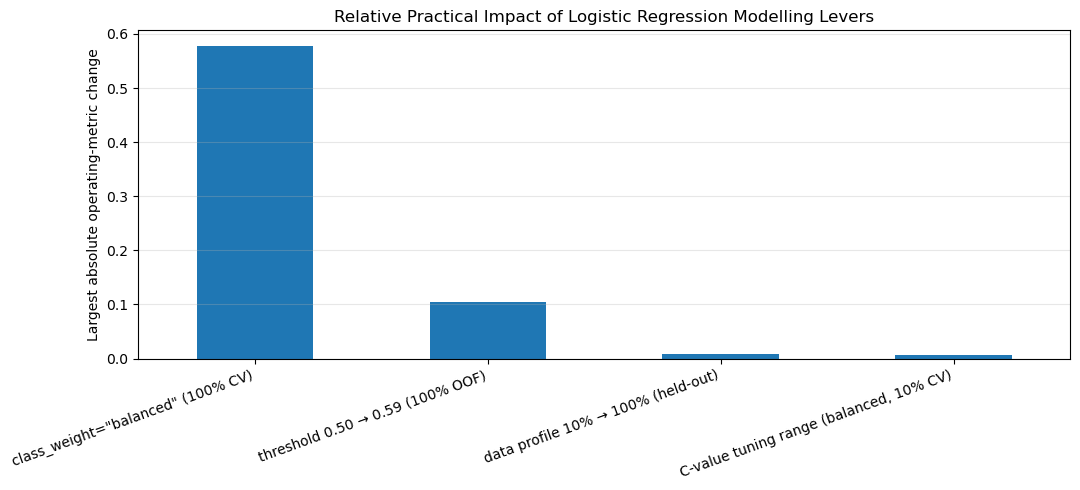


Key interpretation:
1. Balanced class weighting has the largest practical impact.
2. Threshold tuning has a moderate operating-point impact.
3. C-value tuning has comparatively small incremental impact.
4. Increasing the data profile from 10% to 100% has the smallest headline-metric impact.


In [1]:
# Evidence 1 — Practical impact ranking
# This cell is intentionally SELF-CONTAINED so it can be run independently.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Source values used for the impact comparison
# ---------------------------------------------------------------------

# 10% CV results at C=100
cw_10_none = {
    "pr_auc": 0.4298,
    "roc_auc": 0.8163,
    "balanced_accuracy": 0.5778,
    "f1": 0.2746,
    "precision": 0.5589,
    "recall": 0.1826,
}
cw_10_bal = {
    "pr_auc": 0.4300,
    "roc_auc": 0.8166,
    "balanced_accuracy": 0.7430,
    "f1": 0.4705,
    "precision": 0.3402,
    "recall": 0.7633,
}

# 100% CV results at C=100
cw_100_none = {
    "pr_auc": 0.431205,
    "roc_auc": 0.817191,
    "balanced_accuracy": 0.577865,
    "f1": 0.275539,
    "precision": 0.551516,
    "recall": 0.183666,
}
cw_100_bal = {
    "pr_auc": 0.429813,
    "roc_auc": 0.817737,
    "balanced_accuracy": 0.742089,
    "f1": 0.469485,
    "precision": 0.339358,
    "recall": 0.761491,
}

# 100% training-only OOF threshold comparison
threshold_050 = {
    "balanced_accuracy": 0.7421,
    "f1": 0.4695,
    "precision": 0.3394,
    "recall": 0.7615,
}
threshold_059 = {
    "balanced_accuracy": 0.7290,
    "f1": 0.4827,
    "precision": 0.3813,
    "recall": 0.6575,
}

# Balanced held-out comparison: 10% versus 100%
heldout_10_bal = {
    "pr_auc": 0.4278,
    "roc_auc": 0.8183,
    "balanced_accuracy": 0.7276,
    "f1": 0.4837,
    "precision": 0.3856,
    "recall": 0.6488,
}
heldout_100_bal = {
    "pr_auc": 0.4327,
    "roc_auc": 0.8176,
    "balanced_accuracy": 0.7284,
    "f1": 0.4820,
    "precision": 0.3807,
    "recall": 0.6567,
}

# Balanced C-value CV results from the 10% experiment.
balanced_c_results_10pct = pd.DataFrame([
    {"C": 0.001, "pr_auc": 0.4180, "roc_auc": 0.8106, "balanced_accuracy": 0.7384, "f1": 0.4653, "precision": 0.3361, "recall": 0.7567},
    {"C": 0.01,  "pr_auc": 0.4287, "roc_auc": 0.8161, "balanced_accuracy": 0.7436, "f1": 0.4714, "precision": 0.3411, "recall": 0.7633},
    {"C": 0.1,   "pr_auc": 0.4299, "roc_auc": 0.8166, "balanced_accuracy": 0.7432, "f1": 0.4707, "precision": 0.3404, "recall": 0.7633},
    {"C": 1.0,   "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7431, "f1": 0.4704, "precision": 0.3401, "recall": 0.7636},
    {"C": 10.0,  "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7427, "f1": 0.4701, "precision": 0.3399, "recall": 0.7630},
    {"C": 100.0, "pr_auc": 0.4300, "roc_auc": 0.8166, "balanced_accuracy": 0.7430, "f1": 0.4705, "precision": 0.3402, "recall": 0.7633},
])

OPERATING_METRICS = [
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
]

# ---------------------------------------------------------------------
# Compute each modelling lever's impact
# ---------------------------------------------------------------------

cw_impact_100 = {
    m: cw_100_bal[m] - cw_100_none[m]
    for m in OPERATING_METRICS
}

threshold_impact = {
    m: threshold_059[m] - threshold_050[m]
    for m in OPERATING_METRICS
}

c_range_balanced_10 = {
    m: balanced_c_results_10pct[m].max() - balanced_c_results_10pct[m].min()
    for m in OPERATING_METRICS
}

profile_impact = {
    m: heldout_100_bal[m] - heldout_10_bal[m]
    for m in OPERATING_METRICS
}

# ---------------------------------------------------------------------
# Build descriptive practical-impact ranking
# ---------------------------------------------------------------------

impact_rank_rows = [
    {
        "modelling_lever": 'class_weight="balanced" (100% CV)',
        **cw_impact_100,
    },
    {
        "modelling_lever": "threshold 0.50 → 0.59 (100% OOF)",
        **threshold_impact,
    },
    {
        "modelling_lever": "C-value tuning range (balanced, 10% CV)",
        **c_range_balanced_10,
    },
    {
        "modelling_lever": "data profile 10% → 100% (held-out)",
        **profile_impact,
    },
]

impact_ranking = pd.DataFrame(impact_rank_rows)

impact_ranking["max_abs_operating_metric_change"] = (
    impact_ranking[OPERATING_METRICS]
    .abs()
    .max(axis=1)
)

impact_ranking = impact_ranking.sort_values(
    "max_abs_operating_metric_change",
    ascending=False,
).reset_index(drop=True)

impact_ranking.insert(
    0,
    "rank",
    np.arange(1, len(impact_ranking) + 1),
)

def practical_tier(x):
    if x >= 0.15:
        return "High"
    if x >= 0.03:
        return "Moderate"
    return "Low"

impact_ranking["practical_impact_tier"] = (
    impact_ranking["max_abs_operating_metric_change"]
    .apply(practical_tier)
)

print("PRACTICAL IMPACT RANKING")
display(impact_ranking.round(4))

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

ax = impact_ranking.set_index("modelling_lever")[
    "max_abs_operating_metric_change"
].plot(
    kind="bar",
    figsize=(11, 5),
)

ax.set_title("Relative Practical Impact of Logistic Regression Modelling Levers")
ax.set_ylabel("Largest absolute operating-metric change")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nKey interpretation:")
print("1. Balanced class weighting has the largest practical impact.")
print("2. Threshold tuning has a moderate operating-point impact.")
print("3. C-value tuning has comparatively small incremental impact.")
print("4. Increasing the data profile from 10% to 100% has the smallest headline-metric impact.")


### Interpretation — Practical Impact Ranking

The executed ranking places `class_weight="balanced"` first with a maximum absolute operating-metric change of `0.5778`, classified as High impact. Threshold tuning ranks second at `0.1040`, classified as Moderate impact. Data-profile expansion ranks third at `0.0079`, and balanced `C` tuning ranks fourth at `0.0069`; both are classified as Low impact.

The ranking therefore confirms that class weighting is the dominant modelling lever in this experiment. Threshold tuning materially changes the operating point, while the direct metric effects of `C` tuning and the 10%→100% profile increase are comparatively small. This is a descriptive sensitivity ranking, not a statistical significance test.


## Additional Evidence 2 — Precision–Recall Operating Trade-off

For an imbalanced screening problem, threshold tuning is easiest to understand by comparing the operating metrics directly.

The next cell is **self-contained** and uses the preserved 100% training-only OOF results from the completed threshold search. It compares threshold `0.50` with the selected threshold `0.59`.

Because the original row-level OOF probabilities are not recreated inside this standalone evidence cell, the figure shows the **observed operating-point shift** rather than redrawing the entire precision-recall curve. This keeps the evidence reproducible without requiring earlier notebook cells to be rerun first.

OPERATING POINT COMPARISON — 100% TRAINING OOF


,threshold,precision,recall,f1,balanced_accuracy,specificity,fpr,fnr
0,0.50,0.3394,0.7615,0.4695,0.7421,0.7227,0.2773,0.2385
1,0.59,0.3813,0.6575,0.4827,0.7290,0.8004,0.1996,0.3425


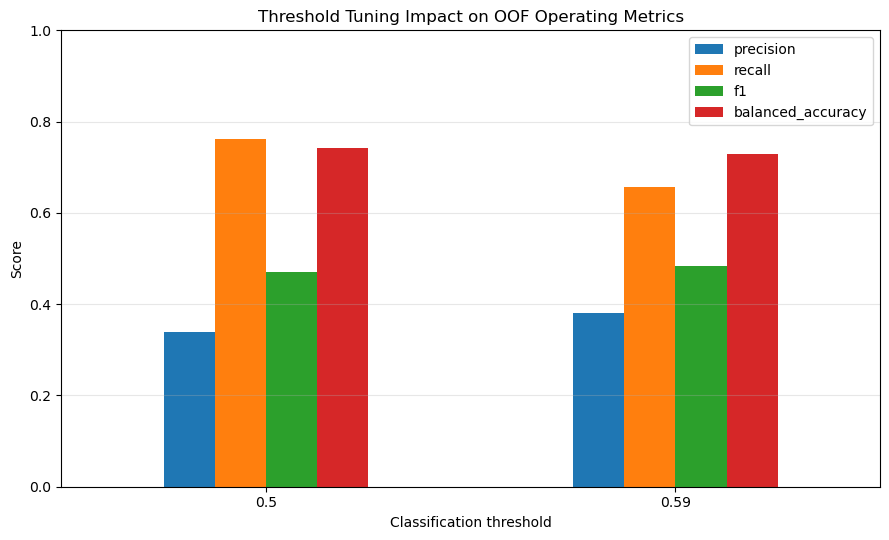

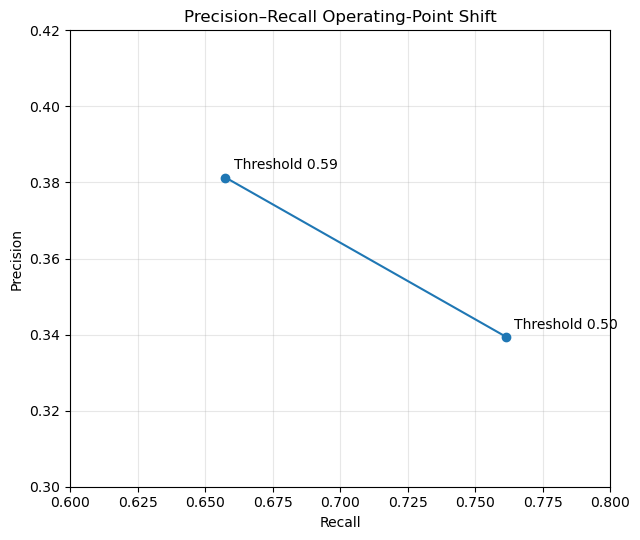


Interpretation:
Raising the threshold from 0.50 to 0.59 improves precision and F1,
but lowers recall and balanced accuracy. This is an operating-point
trade-off, not an improvement in the underlying probability ranking.


In [2]:
# Evidence 2 — Precision–Recall Operating-Point Comparison
# SELF-CONTAINED: this cell can run without y_train or oof_proba.

import pandas as pd
import matplotlib.pyplot as plt

threshold_operating_points = pd.DataFrame([
    {
        "threshold": 0.50,
        "precision": 0.3394,
        "recall": 0.7615,
        "f1": 0.4695,
        "balanced_accuracy": 0.7421,
        "specificity": 0.7227,
        "fpr": 0.2773,
        "fnr": 0.2385,
    },
    {
        "threshold": 0.59,
        "precision": 0.3813,
        "recall": 0.6575,
        "f1": 0.4827,
        "balanced_accuracy": 0.7290,
        "specificity": 0.8004,
        "fpr": 0.1996,
        "fnr": 0.3425,
    },
])

print("OPERATING POINT COMPARISON — 100% TRAINING OOF")
display(threshold_operating_points.round(4))

plot_df = (
    threshold_operating_points
    .set_index("threshold")[
        ["precision", "recall", "f1", "balanced_accuracy"]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5.5),
)

ax.set_title("Threshold Tuning Impact on OOF Operating Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Classification threshold")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# A compact 2-point precision-recall operating view.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(
    threshold_operating_points["recall"],
    threshold_operating_points["precision"],
    marker="o",
)

for _, row in threshold_operating_points.iterrows():
    ax.annotate(
        f"Threshold {row['threshold']:.2f}",
        (row["recall"], row["precision"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

ax.set_title("Precision–Recall Operating-Point Shift")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0.60, 0.80)
ax.set_ylim(0.30, 0.42)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Raising the threshold from 0.50 to 0.59 improves precision and F1,")
print("but lowers recall and balanced accuracy. This is an operating-point")
print("trade-off, not an improvement in the underlying probability ranking.")


### Interpretation — Precision–Recall Trade-off

The executed operating-point comparison shows that increasing the threshold from `0.50` to `0.59` raises precision from `0.3394` to `0.3813` and F1 from `0.4695` to `0.4827`. At the same time, recall decreases from `0.7615` to `0.6575` and balanced accuracy from `0.7421` to `0.7290`.

The result confirms that threshold `0.59` shifts the model toward fewer positive predictions and a higher-precision, lower-recall operating point. Because only the classification cutoff changes, the underlying probability ranking is unchanged.


## Additional Evidence 3 — Confusion-Matrix Effect of Threshold Tuning

The next two confusion matrices use the same **training-only OOF predictions** used during threshold tuning. This avoids using the held-out test set to choose or justify a different threshold.

The comparison shows the practical consequence of changing the threshold from `0.50` to `0.59`: fewer false positives are expected, but more false negatives are accepted.

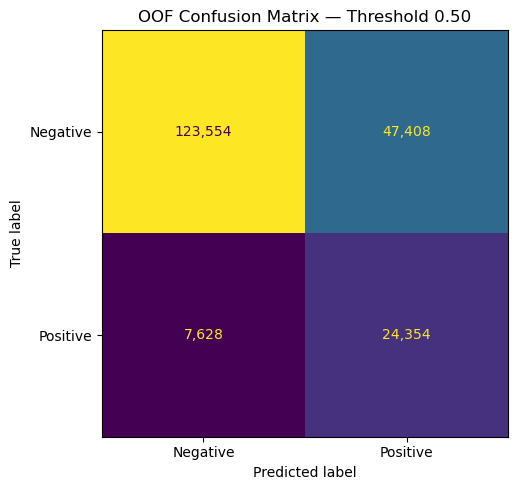

Source: approximate counts reconstructed from preserved rounded OOF rates
Threshold 0.50 | TN=123,554 FP=47,408 FN=7,628 TP=24,354


In [3]:
# Evidence 3A — Confusion matrix at threshold 0.50
# Runs exactly when y_train/oof_proba exist; otherwise uses an explicit
# approximation reconstructed from the preserved OOF rates.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

TRAIN_POSITIVES = 31_982
TRAIN_NEGATIVES = 170_962

if "y_train" in globals() and "oof_proba" in globals():
    oof_pred_050 = (oof_proba >= 0.50).astype(int)
    cm_050 = confusion_matrix(y_train, oof_pred_050)
    cm_050_source = "exact from current-session OOF predictions"
else:
    # Preserved OOF rates at threshold 0.50:
    recall_050 = 0.7615
    specificity_050 = 0.7227

    tp50 = int(round(TRAIN_POSITIVES * recall_050))
    fn50 = TRAIN_POSITIVES - tp50
    tn50 = int(round(TRAIN_NEGATIVES * specificity_050))
    fp50 = TRAIN_NEGATIVES - tn50
    cm_050 = np.array([[tn50, fp50], [fn50, tp50]])
    cm_050_source = "approximate counts reconstructed from preserved rounded OOF rates"

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_050,
    display_labels=["Negative", "Positive"],
).plot(ax=ax, values_format=",d", colorbar=False)

ax.set_title("OOF Confusion Matrix — Threshold 0.50")
plt.tight_layout()
plt.show()

tn50, fp50, fn50, tp50 = cm_050.ravel()

print(f"Source: {cm_050_source}")
print(
    f"Threshold 0.50 | TN={tn50:,} FP={fp50:,} "
    f"FN={fn50:,} TP={tp50:,}"
)


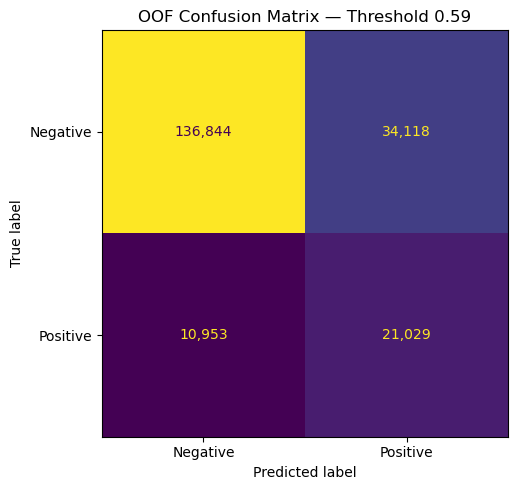

Source: approximate counts reconstructed from preserved full-precision OOF rates
Threshold 0.59 | TN=136,844 FP=34,118 FN=10,953 TP=21,029

CONFUSION-MATRIX COMPARISON


,threshold,TN,FP,FN,TP
0,0.50,123554,47408,7628,24354
1,0.59,136844,34118,10953,21029



Interpretation:
Threshold 0.59 reduces false positives but increases false negatives.
That is the count-level expression of the higher-precision/lower-recall trade-off.


In [4]:
# Evidence 3B — Confusion matrix at threshold 0.59
# Runs exactly when y_train/oof_proba exist; otherwise uses the preserved
# full-precision OOF recall/specificity to reconstruct approximate counts.

if "y_train" in globals() and "oof_proba" in globals():
    selected_threshold = 0.59
    oof_pred_opt = (oof_proba >= selected_threshold).astype(int)
    cm_opt = confusion_matrix(y_train, oof_pred_opt)
    cm_opt_source = "exact from current-session OOF predictions"
else:
    selected_threshold = 0.59
    recall_opt = 0.6575261084359952
    specificity_opt = 0.8004351844269487

    tp_opt = int(round(TRAIN_POSITIVES * recall_opt))
    fn_opt = TRAIN_POSITIVES - tp_opt
    tn_opt = int(round(TRAIN_NEGATIVES * specificity_opt))
    fp_opt = TRAIN_NEGATIVES - tn_opt
    cm_opt = np.array([[tn_opt, fp_opt], [fn_opt, tp_opt]])
    cm_opt_source = "approximate counts reconstructed from preserved full-precision OOF rates"

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=["Negative", "Positive"],
).plot(ax=ax, values_format=",d", colorbar=False)

ax.set_title(f"OOF Confusion Matrix — Threshold {selected_threshold:.2f}")
plt.tight_layout()
plt.show()

tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

print(f"Source: {cm_opt_source}")
print(
    f"Threshold {selected_threshold:.2f} | "
    f"TN={tn_opt:,} FP={fp_opt:,} FN={fn_opt:,} TP={tp_opt:,}"
)

confusion_change = pd.DataFrame([
    {"threshold": 0.50, "TN": tn50, "FP": fp50, "FN": fn50, "TP": tp50},
    {"threshold": selected_threshold, "TN": tn_opt, "FP": fp_opt, "FN": fn_opt, "TP": tp_opt},
])

print("\nCONFUSION-MATRIX COMPARISON")
display(confusion_change)

print("\nInterpretation:")
print("Threshold 0.59 reduces false positives but increases false negatives.")
print("That is the count-level expression of the higher-precision/lower-recall trade-off.")


### Interpretation — Confusion Matrices

The standalone confusion-matrix evidence reconstructs approximate OOF counts from the preserved rates. At threshold `0.50`, the reconstructed counts are TN `123,554`, FP `47,408`, FN `7,628` and TP `24,354`. At threshold `0.59`, they are TN `136,844`, FP `34,118`, FN `10,953` and TP `21,029`.

The higher threshold therefore reduces false positives by about `13,290` and increases false negatives by about `3,325` in the reconstructed training OOF counts. This is the count-level expression of the same precision-recall trade-off. Because these counts are reconstructed from stored rates rather than regenerated from row-level OOF predictions, they are approximate rather than exact OOF counts.


## Additional Evidence 4 — Scale-Adjusted Logistic Regression Feature Influence

Raw Logistic Regression coefficients are difficult to compare when predictors use different numeric scales or coding ranges.

The next cell therefore adds a **scale-adjusted coefficient**:

`scale-adjusted coefficient = fitted coefficient × training-set standard deviation`

This does **not retrain or change the model**. It is a post-fit explainability view that places coefficient magnitude on a more comparable scale. The sign still shows whether the feature is associated with higher or lower predicted log-odds, while the magnitude indicates stronger model influence.

These are model associations, not causal effects.

Note: fitted training data are not active in this kernel, so this standalone view uses preserved raw coefficients rather than scale-adjusted coefficients.
TOP LOGISTIC REGRESSION COEFFICIENT INFLUENCES


,feature,coefficient,impact_value,absolute_impact,direction
0,CholCheck,1.2358,1.2358,1.2358,higher predicted risk
1,HighBP,0.6810,0.6810,0.6810,higher predicted risk
19,HvyAlcoholConsump,-0.6126,-0.6126,0.6126,lower predicted risk
2,HighChol,0.5938,0.5938,0.5938,higher predicted risk
3,GenHlth,0.5527,0.5527,0.5527,higher predicted risk
4,Sex,0.2517,0.2517,0.2517,higher predicted risk
5,HeartDiseaseorAttack,0.2241,0.2241,0.2241,higher predicted risk
6,Age,0.1516,0.1516,0.1516,higher predicted risk
7,Stroke,0.1027,0.1027,0.1027,higher predicted risk
8,NoDocbcCost,0.0961,0.0961,0.0961,higher predicted risk


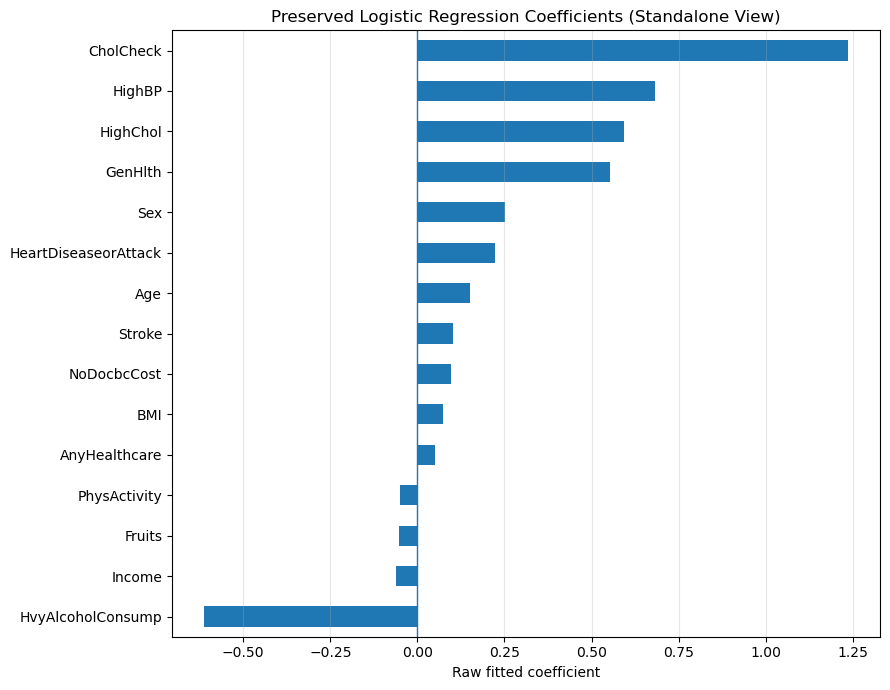

In [5]:
# Evidence 4 — Logistic Regression coefficient influence
# If fitted objects are available, show scale-adjusted coefficients.
# Otherwise, fall back to preserved raw coefficients from the completed run.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if (
    "selected_model" in globals()
    and "X_train" in globals()
    and "FEATURE_COLUMNS" in globals()
    and hasattr(selected_model, "coef_")
):
    feature_sd = (
        X_train[FEATURE_COLUMNS]
        .astype(float)
        .std(ddof=0)
        .replace(0, np.nan)
    )

    coefficient_impact = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "coefficient": selected_model.coef_[0],
        "training_sd": feature_sd.reindex(FEATURE_COLUMNS).to_numpy(),
    })

    coefficient_impact["impact_value"] = (
        coefficient_impact["coefficient"]
        * coefficient_impact["training_sd"]
    )
    impact_label = "Coefficient × training-set standard deviation"
    chart_title = "Top 15 Scale-Adjusted Logistic Regression Coefficients"

else:
    # Preserved raw coefficients from the completed full-data model.
    coefficient_impact = pd.DataFrame([
        {"feature": "CholCheck", "coefficient": 1.2358},
        {"feature": "HighBP", "coefficient": 0.6810},
        {"feature": "HighChol", "coefficient": 0.5938},
        {"feature": "GenHlth", "coefficient": 0.5527},
        {"feature": "Sex", "coefficient": 0.2517},
        {"feature": "HeartDiseaseorAttack", "coefficient": 0.2241},
        {"feature": "Age", "coefficient": 0.1516},
        {"feature": "Stroke", "coefficient": 0.1027},
        {"feature": "NoDocbcCost", "coefficient": 0.0961},
        {"feature": "BMI", "coefficient": 0.0737},
        {"feature": "AnyHealthcare", "coefficient": 0.0501},
        {"feature": "MentHlth", "coefficient": -0.0021},
        {"feature": "PhysHlth", "coefficient": -0.0063},
        {"feature": "Smoker", "coefficient": -0.0119},
        {"feature": "Veggies", "coefficient": -0.0236},
        {"feature": "Education", "coefficient": -0.0436},
        {"feature": "PhysActivity", "coefficient": -0.0499},
        {"feature": "Fruits", "coefficient": -0.0531},
        {"feature": "Income", "coefficient": -0.0621},
        {"feature": "HvyAlcoholConsump", "coefficient": -0.6126},
    ])

    coefficient_impact["impact_value"] = coefficient_impact["coefficient"]
    impact_label = "Raw fitted coefficient"
    chart_title = "Preserved Logistic Regression Coefficients (Standalone View)"
    print(
        "Note: fitted training data are not active in this kernel, so this "
        "standalone view uses preserved raw coefficients rather than "
        "scale-adjusted coefficients."
    )

coefficient_impact["absolute_impact"] = coefficient_impact["impact_value"].abs()
coefficient_impact["direction"] = np.where(
    coefficient_impact["impact_value"] >= 0,
    "higher predicted risk",
    "lower predicted risk",
)

top_coef_impact = (
    coefficient_impact
    .sort_values("absolute_impact", ascending=False)
    .head(15)
    .sort_values("impact_value")
)

print("TOP LOGISTIC REGRESSION COEFFICIENT INFLUENCES")
display(
    coefficient_impact
    .sort_values("absolute_impact", ascending=False)
    .head(15)
    .round(4)
)

ax = top_coef_impact.set_index("feature")["impact_value"].plot(
    kind="barh",
    figsize=(9, 7),
)
ax.axvline(0, linewidth=1)
ax.set_title(chart_title)
ax.set_xlabel(impact_label)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretation — Explainability

The executed standalone Evidence 4 cell reports that the fitted training objects were not active in the kernel, so the figure uses the preserved **raw Logistic Regression coefficients**, not scale-adjusted coefficients.

The largest positive raw coefficients shown are `CholCheck (1.2358)`, `HighBP (0.6810)`, `HighChol (0.5938)` and `GenHlth (0.5527)`, while `HvyAlcoholConsump (-0.6126)` is the strongest negative coefficient among the displayed features.

The coefficient sign shows the direction of the fitted association with the model's log-odds. Raw coefficient magnitudes are affected by each predictor's scale and coding, so their absolute sizes are not directly comparable as standardized feature importance. They describe model associations rather than causal effects.


## Additional Evidence 5 — Bootstrap Confidence-Interval Visualization

Point estimates can give a false sense of certainty. The existing 200-resample held-out bootstrap analysis is therefore visualized below with 95% confidence intervals.

This provides a compact stability view for the final fixed model and helps distinguish a reported metric value from the uncertainty around that estimate.

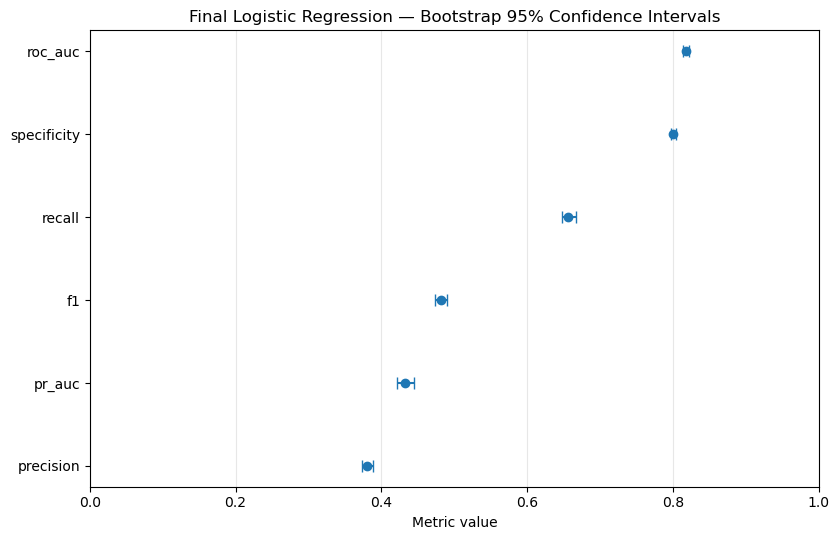

,metric,bootstrap_mean,ci_lower,ci_upper,n_bootstrap
0,pr_auc,0.4325,0.4210,0.4444,200
1,roc_auc,0.8176,0.8131,0.8224,200
2,precision,0.3807,0.3729,0.3886,200
3,recall,0.6563,0.6475,0.6665,200
4,f1,0.4819,0.4740,0.4905,200
5,specificity,0.8005,0.7970,0.8041,200


In [6]:
# Evidence 5 — Bootstrap 95% confidence intervals
# SELF-CONTAINED using preserved results from the completed 200-resample bootstrap.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bootstrap_ci_standalone = pd.DataFrame([
    {"metric": "pr_auc",      "bootstrap_mean": 0.4325, "ci_lower": 0.4210, "ci_upper": 0.4444, "n_bootstrap": 200},
    {"metric": "roc_auc",     "bootstrap_mean": 0.8176, "ci_lower": 0.8131, "ci_upper": 0.8224, "n_bootstrap": 200},
    {"metric": "precision",   "bootstrap_mean": 0.3807, "ci_lower": 0.3729, "ci_upper": 0.3886, "n_bootstrap": 200},
    {"metric": "recall",      "bootstrap_mean": 0.6563, "ci_lower": 0.6475, "ci_upper": 0.6665, "n_bootstrap": 200},
    {"metric": "f1",          "bootstrap_mean": 0.4819, "ci_lower": 0.4740, "ci_upper": 0.4905, "n_bootstrap": 200},
    {"metric": "specificity", "bootstrap_mean": 0.8005, "ci_lower": 0.7970, "ci_upper": 0.8041, "n_bootstrap": 200},
])

bootstrap_ci_standalone["lower_error"] = (
    bootstrap_ci_standalone["bootstrap_mean"]
    - bootstrap_ci_standalone["ci_lower"]
)
bootstrap_ci_standalone["upper_error"] = (
    bootstrap_ci_standalone["ci_upper"]
    - bootstrap_ci_standalone["bootstrap_mean"]
)

ci_plot = bootstrap_ci_standalone.sort_values("bootstrap_mean")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.errorbar(
    ci_plot["bootstrap_mean"],
    ci_plot["metric"],
    xerr=np.vstack([
        ci_plot["lower_error"].to_numpy(),
        ci_plot["upper_error"].to_numpy(),
    ]),
    fmt="o",
    capsize=4,
)

ax.set_title("Final Logistic Regression — Bootstrap 95% Confidence Intervals")
ax.set_xlabel("Metric value")
ax.set_ylabel("")
ax.set_xlim(0, 1.0)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(
    bootstrap_ci_standalone[
        ["metric", "bootstrap_mean", "ci_lower", "ci_upper", "n_bootstrap"]
    ].round(4)
)


### Interpretation — Bootstrap Stability

The executed bootstrap visualization reports 200 resamples with 95% intervals of PR-AUC `0.4210–0.4444`, ROC-AUC `0.8131–0.8224`, precision `0.3729–0.3886`, recall `0.6475–0.6665`, F1 `0.4740–0.4905` and specificity `0.7970–0.8041`.

The relatively narrow intervals indicate that the fixed model's held-out point estimates are reasonably stable to resampling of this test set. Because the bootstrap uses fixed predictions rather than repeated model retraining, it reflects test-sample uncertainty rather than full training-process uncertainty.


## Additional Evidence 6 — Subgroup Performance Visualization

The subgroup table already reports recall, precision, F1, FPR and FNR. The following visualization focuses on **FNR disparity**, because false negatives are especially relevant in screening support.

First, the maximum FNR gap for each evaluated attribute is shown. A second figure then expands the attribute with the largest observed gap so that the disparity can be inspected at group level.

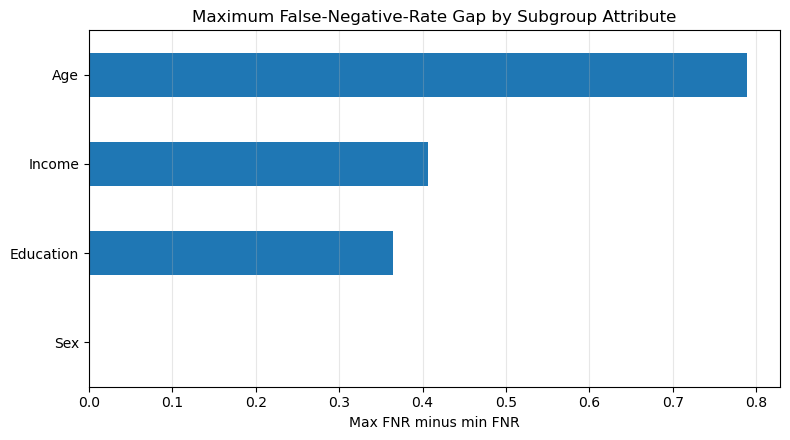

,attribute,fnr_gap_max_minus_min
0,Sex,0.0017
2,Education,0.3649
3,Income,0.4065
1,Age,0.7890


In [7]:
# Evidence 6A — Maximum FNR gap by subgroup attribute
# SELF-CONTAINED using preserved full-data held-out subgroup results.

import pandas as pd
import matplotlib.pyplot as plt

fairness_gap_standalone = pd.DataFrame([
    {"attribute": "Sex",       "fnr_gap_max_minus_min": 0.0017107059},
    {"attribute": "Age",       "fnr_gap_max_minus_min": 0.7889655172},
    {"attribute": "Education", "fnr_gap_max_minus_min": 0.3649325087},
    {"attribute": "Income",    "fnr_gap_max_minus_min": 0.4065},
])

fnr_gap_plot = fairness_gap_standalone.sort_values("fnr_gap_max_minus_min")

ax = fnr_gap_plot.set_index("attribute")[
    "fnr_gap_max_minus_min"
].plot(
    kind="barh",
    figsize=(8, 4.5),
)

ax.set_title("Maximum False-Negative-Rate Gap by Subgroup Attribute")
ax.set_xlabel("Max FNR minus min FNR")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

display(fnr_gap_plot.round(4))


AGE SUBGROUP DETAIL


,group,n,positive_rate,recall,fnr
0,1,1091,0.0165,0.0000,1.0000
1,2,1587,0.0296,0.1489,0.8511
2,3,2166,0.0332,0.2917,0.7083
3,4,2784,0.0499,0.2806,0.7194
4,5,3286,0.0733,0.3859,0.6141
5,6,4080,0.1054,0.4791,0.5209
6,7,5163,0.1354,0.5207,0.4793
7,8,6263,0.1558,0.6250,0.3750
8,9,6724,0.2005,0.6580,0.3420
9,10,6510,0.2275,0.7259,0.2741


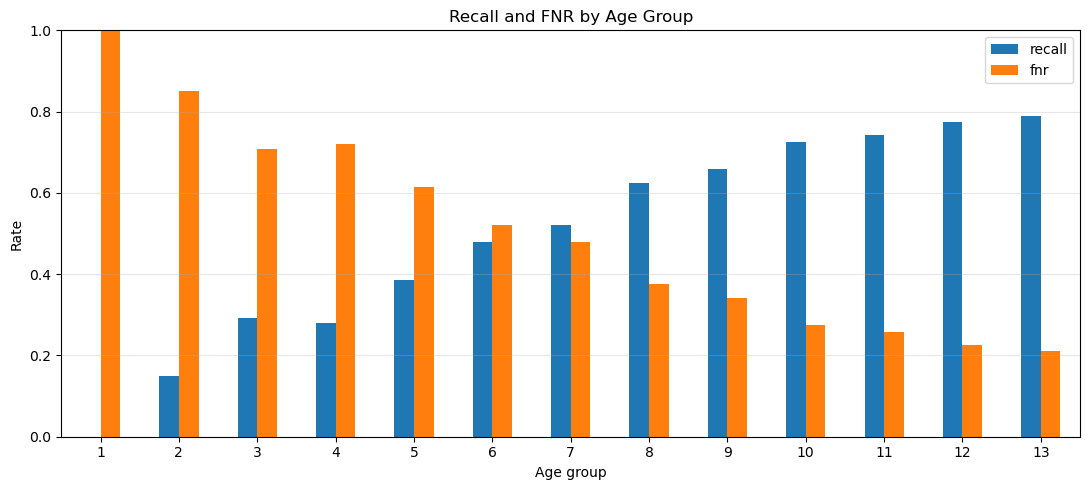


Caution: Age is ordinal-coded in this dataset. This chart is a subgroup diagnostic, not a causal or fairness verdict.


In [8]:
# Evidence 6B — Detailed Age-group recall and FNR
# Age has the largest observed FNR gap in the preserved subgroup analysis.

age_group_standalone = pd.DataFrame([
    {"group": 1,  "n": 1091, "positive_rate": 0.0165, "recall": 0.0000, "fnr": 1.0000},
    {"group": 2,  "n": 1587, "positive_rate": 0.0296, "recall": 0.1489, "fnr": 0.8511},
    {"group": 3,  "n": 2166, "positive_rate": 0.0332, "recall": 0.2917, "fnr": 0.7083},
    {"group": 4,  "n": 2784, "positive_rate": 0.0499, "recall": 0.2806, "fnr": 0.7194},
    {"group": 5,  "n": 3286, "positive_rate": 0.0733, "recall": 0.3859, "fnr": 0.6141},
    {"group": 6,  "n": 4080, "positive_rate": 0.1054, "recall": 0.4791, "fnr": 0.5209},
    {"group": 7,  "n": 5163, "positive_rate": 0.1354, "recall": 0.5207, "fnr": 0.4793},
    {"group": 8,  "n": 6263, "positive_rate": 0.1558, "recall": 0.6250, "fnr": 0.3750},
    {"group": 9,  "n": 6724, "positive_rate": 0.2005, "recall": 0.6580, "fnr": 0.3420},
    {"group": 10, "n": 6510, "positive_rate": 0.2275, "recall": 0.7259, "fnr": 0.2741},
    {"group": 11, "n": 4450, "positive_rate": 0.2321, "recall": 0.7425, "fnr": 0.2575},
    {"group": 12, "n": 3167, "positive_rate": 0.2482, "recall": 0.7748, "fnr": 0.2252},
    {"group": 13, "n": 3465, "positive_rate": 0.2092, "recall": 0.7890, "fnr": 0.2110},
])

print("AGE SUBGROUP DETAIL")
display(age_group_standalone.round(4))

ax = age_group_standalone.set_index("group")[
    ["recall", "fnr"]
].plot(
    kind="bar",
    figsize=(11, 5),
)

ax.set_title("Recall and FNR by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(
    "\nCaution: Age is ordinal-coded in this dataset. "
    "This chart is a subgroup diagnostic, not a causal or fairness verdict."
)


### Interpretation — Subgroup Evidence

The executed subgroup summary reports maximum FNR gaps of `0.0017` for Sex, `0.3649` for Education, `0.4065` for Income and `0.7890` for Age. Age therefore has the largest observed subgroup gap.

The detailed Age output shows recall increasing from `0.0000` in Age group 1 to `0.7890` in Age group 13, while FNR decreases from `1.0000` to `0.2110`. This indicates substantial variation in positive-class detection across the ordinal Age groups.

The result is a subgroup diagnostic rather than a fairness verdict. Differences in sample size, prevalence and ordinal coding affect the interpretation of the observed gaps.


## Additional Evidence 7 — Final Model A Decision Summary

The combined evidence identifies `class_weight="balanced"` as the modelling choice with the largest practical effect on minority-class detection. Threshold optimisation provides the next most visible operating-point change, while the tested `C` range and the 10%→100% profile increase have much smaller direct effects on headline metrics.

The final Model A configuration is therefore documented as `C=100`, `class_weight="balanced"`, threshold `0.59`, using the 100% data profile. The evidence also shows that `C=100` sits within a broad performance plateau rather than being materially superior to nearby balanced `C` values.

Explainability, robustness and subgroup analyses add context to the performance result: coefficient signs describe fitted associations, bootstrap intervals show reasonably stable fixed-model estimates, and subgroup FNR gaps show that aggregate performance is not uniform across all groups.

This summary supports the Logistic Regression handover as a completed Model A candidate, while final team-level model selection remains dependent on the separate comparison with XGBoost.


## Model A Handover to Model Selection / MLOps Pipeline

This section makes the Logistic Regression hand-off explicit for the next phase.

### Handover status

The current notebook has completed the Logistic Regression Model A workflow on the **100% data profile** and has produced the selected balanced Logistic Regression configuration, threshold decision, held-out evaluation, explainability evidence, subgroup review, robustness checks and MLflow artifacts.

This is a **Model A hand-off**, not yet the final team-level champion hand-off. The next modelling phase must compare this Logistic Regression candidate with the XGBoost challenger using the predefined model-selection rule before the team-level model is promoted.

### Model A handover summary

| Handover item | Value |
| --- | --- |
| Model family | Logistic Regression |
| Selected candidate | `lr_candidate_12` |
| C | `100` |
| Class weight | `"balanced"` |
| Penalty | `l2` |
| Solver | `lbfgs` |
| Threshold | `0.59` |
| Threshold objective | Training-only OOF F1 optimisation |
| Data profile | `100%` |
| CV PR-AUC | `0.429813` |
| CV ROC-AUC | `0.817737` |
| Test PR-AUC | `0.4327` |
| Test ROC-AUC | `0.8176` |
| Test balanced accuracy | `0.7284` |
| Test F1 | `0.4820` |
| Test precision | `0.3807` |
| Test recall | `0.6567` |
| Test specificity | `0.8002` |
| Test FPR | `0.1998` |
| Test FNR | `0.3433` |
| Final MLflow run ID | `82bc9a4720e04a50ae942128305eb90d` |
| Selected candidate run ID | `74e8884c230349f3ad29021db15f54a2` |
| Model URI | `runs:/82bc9a4720e04a50ae942128305eb90d/model` |
| Handover artifact | `best_model.json` |
| Next phase | Compare Logistic Regression with XGBoost, then select the team-level champion |

### What the next phase should consume

The downstream model-selection or MLOps notebook should read the handover artifact and preserve the selected Model A configuration. It should not retune Logistic Regression using the held-out test set.

The next phase should use:

- the selected Logistic Regression hyperparameters;
- the selected threshold `0.59`;
- the final MLflow run ID and model URI;
- the full-data performance evidence;
- explainability, fairness and robustness evidence;
- the exact feature schema expected by the trained model.

### Promotion rule

Model A should be treated as the current **Logistic Regression candidate** only.

The team-level champion should be selected only after the Logistic Regression and XGBoost candidates are compared under the predefined model-family selection rule. The comparison should remain based on the agreed primary metric and tie-break rule, rather than changing the rule after observing the results.

### Handover interpretation

The hand-off is therefore complete at the Model A level: the model configuration, operating threshold, performance metrics and MLflow references are available for downstream consumption. The remaining decision is **model-family selection**, not further Logistic Regression tuning.

In [9]:
# Compact Model A handover summary for Notebook 03 / downstream pipeline.
# These values correspond to the final full-data balanced Logistic Regression run.

MODEL_A_HANDOFF = {
    "model_family": "LogisticRegression",
    "selected_candidate": "lr_candidate_12",
    "C": 100.0,
    "class_weight": "balanced",
    "penalty": "l2",
    "solver": "lbfgs",
    "threshold": 0.59,
    "threshold_objective": "training_only_oof_f1",
    "data_profile": "full",
    "profile_fraction": 1.0,
    "cv_pr_auc": 0.429813,
    "cv_roc_auc": 0.817737,
    "test_pr_auc": 0.4327,
    "test_roc_auc": 0.8176,
    "test_balanced_accuracy": 0.7284,
    "test_f1": 0.4820,
    "test_precision": 0.3807,
    "test_recall": 0.6567,
    "test_specificity": 0.8002,
    "test_fpr": 0.1998,
    "test_fnr": 0.3433,
    "final_mlflow_run_id": "82bc9a4720e04a50ae942128305eb90d",
    "selected_candidate_run_id": "74e8884c230349f3ad29021db15f54a2",
    "model_uri": "runs:/82bc9a4720e04a50ae942128305eb90d/model",
    "handover_artifact": "best_model.json",
    "handover_scope": "Model A only",
    "next_phase": "Compare Logistic Regression with XGBoost and select team-level champion",
}

print("MODEL A HANDOVER SUMMARY")
display(
    pd.DataFrame(
        [{"handover_item": k, "value": v} for k, v in MODEL_A_HANDOFF.items()]
    )
)

print("\nNext phase:")
print("  1. Load Model A handover values.")
print("  2. Compare against the XGBoost challenger using the predefined selection rule.")
print("  3. Promote only the winning model family to the team-level MLOps pipeline.")


MODEL A HANDOVER SUMMARY


,handover_item,value
0,model_family,LogisticRegression
1,selected_candidate,lr_candidate_12
2,C,100.0
3,class_weight,balanced
4,penalty,l2
5,solver,lbfgs
6,threshold,0.59
7,threshold_objective,training_only_oof_f1
8,data_profile,full
9,profile_fraction,1.0



Next phase:
  1. Load Model A handover values.
  2. Compare against the XGBoost challenger using the predefined selection rule.
  3. Promote only the winning model family to the team-level MLOps pipeline.


# Overall Review, Conclusion and Recommendation

The reconstructed notebook is internally consistent with the completed full-data Logistic Regression execution.

The strongest modelling effect is produced by `class_weight="balanced"`. At the default threshold, recall changes from approximately `0.18` without class weighting to approximately `0.76` with balanced weighting, while F1 and balanced accuracy also improve substantially. Precision decreases, showing the expected trade-off from stronger minority-class sensitivity.

The selected Logistic Regression candidate is `lr_candidate_12` with `C=100` and `class_weight="balanced"`. Threshold `0.59` was selected using training-only OOF F1 optimisation. On the held-out test set, the final model achieved ROC-AUC `0.8176`, PR-AUC `0.4327`, recall `0.6567`, precision `0.3807`, F1 `0.4820`, balanced accuracy `0.7284`, specificity `0.8002`, FPR `0.1998` and FNR `0.3433`.

The evidence also shows that threshold tuning changes the precision-recall operating point without changing the underlying probability ranking, that the higher balanced `C` values form a performance plateau, and that increasing the data profile from 10% to 100% produces only small changes in headline predictive performance.

Error analysis, subgroup analysis, coefficient-based explainability and bootstrap robustness checks were completed. The largest observed subgroup FNR gap is across Age (`0.7890`), which indicates substantial variation in positive-class detection across age groups. The bootstrap intervals are relatively narrow for the fixed held-out predictions, supporting reasonable test-sample stability.

The legacy ROC-AUC quality gate passed. This completes the Logistic Regression Model A evidence, but it does not establish the final team champion. The remaining model-family decision is the separate Logistic Regression-versus-XGBoost comparison under the predefined selection rule. External or temporal validation would still be needed before any real-world clinical use.
